# Data Fetch and Load

In [6]:
import os
import pandas as pd
import kagglehub

data_path = kagglehub.competition_download('titanic')
train_path = os.path.join (data_path, 'train.csv')
test_path = os.path.join (data_path, 'test.csv')
data = pd.read_csv(train_path)
submission = pd.read_csv(test_path)
titanic = data.copy()

all_data = pd.concat ([data.drop ('Survived', axis = 1).copy(), submission], axis = 0)
datasets = [data, submission]

# EDA

In [7]:
all_data.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   str    
 3   Sex          1309 non-null   str    
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   str    
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    str    
 10  Embarked     1307 non-null   str    
dtypes: float64(2), int64(4), str(5)
memory usage: 122.7 KB


In [8]:
print ('----Train----')
count = titanic.isna().sum()
percent = count / titanic.isna().count() * 100
summary = pd.concat ([count, percent], axis = 1, keys = ['Count', 'Percent'])
summary = summary[summary['Percent'] > 0]
print (summary)

print ('----Submission----')
count = submission.isna().sum()
percent = count / submission.isna().count() * 100
summary = pd.concat([count, percent], axis = 1, keys = ['Count', 'Percent'])
summary = summary[summary['Percent'] > 0]
print(); print (summary)

----Train----
          Count    Percent
Age         177  19.865320
Cabin       687  77.104377
Embarked      2   0.224467
----Submission----

       Count    Percent
Age       86  20.574163
Fare       1   0.239234
Cabin    327  78.229665


Fill 'Embarked' in train and 'Fare' in submission set with Median values
#
Cabin will be dropped
# 
Explore ways to fill Age

In [9]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
submission['Fare'] = submission['Fare'].fillna(submission['Fare'].median())

In [10]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


38% of passenger Survived
#
Most passenger aged around 30 yo
#
Average ticket fare is 32 dollars
#
I wonder what are these values for survivors ?

In [11]:
num_attributes = titanic.select_dtypes(include = [int, float]).columns.tolist()
num_attributes.remove('Survived')
pd.pivot_table (titanic, index = 'Survived', values = num_attributes, aggfunc='mean')

,Age,Fare,Parch,PassengerId,Pclass,SibSp
Survived,,,,,,
0,30.626179,22.117887,0.329690,447.016393,2.531876,0.553734
1,28.343690,48.395408,0.464912,444.368421,1.950292,0.473684


Both survivors and dead passengers aged around 30 (survivors are around 28), making me think this feature is not so impactful
#
Survivors pay 48 dollars in average, which means the rich have more chances to survive. Moreover, most survivors are 1st & 2nd class, while dead are around 3rd and 2nd class
# 
Average number of Family companions are not so different between alive and dead passengers

# Feature Engineering & Selection

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

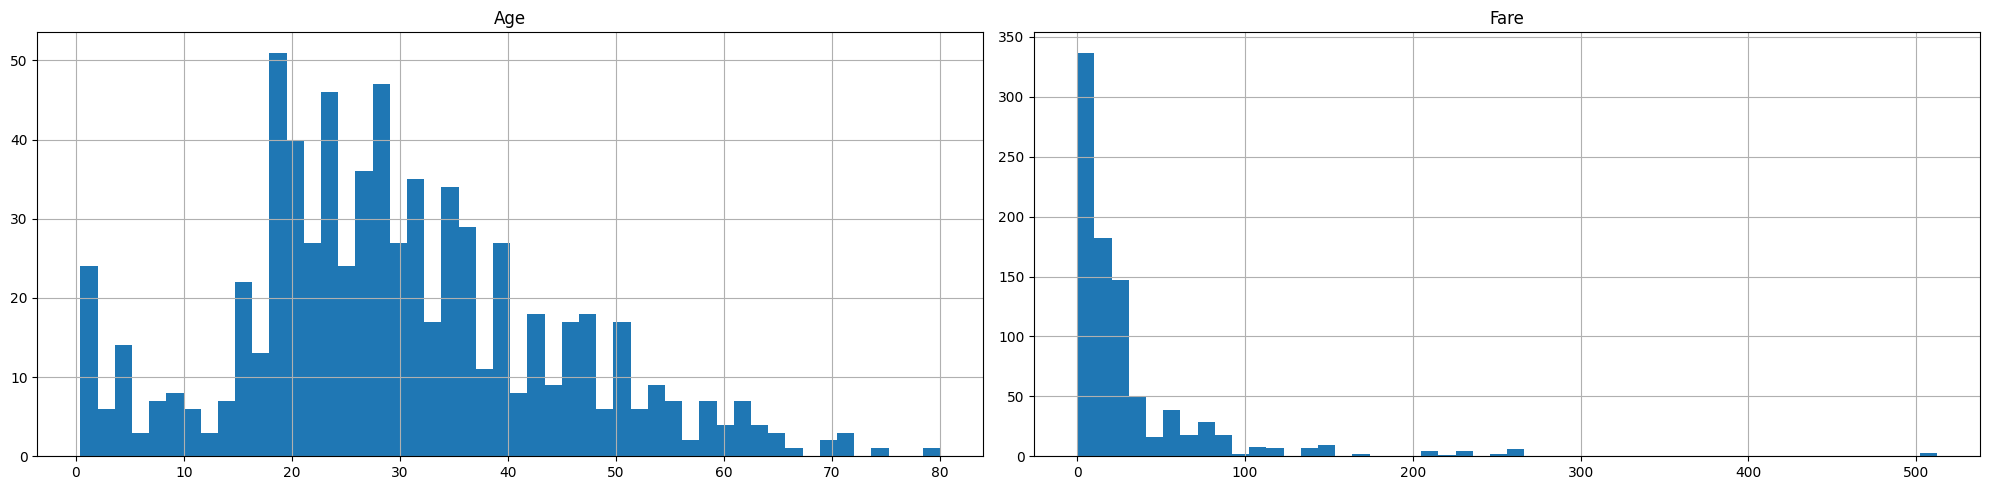

In [13]:
_, axes = plt.subplots (nrows=1, ncols=2, figsize=(20, 5))
titanic['Age'].hist(bins = 50, ax = axes[0]) # Age is normally distributed
titanic['Fare'].hist(bins = 50, ax = axes[1]) # Fare is heavily right skewed, with many outliers
axes[0].set_title ('Age')
axes[1].set_title ('Fare')
plt.tight_layout(); plt.show()

Text(0.5, 1.0, 'Age Range Count')

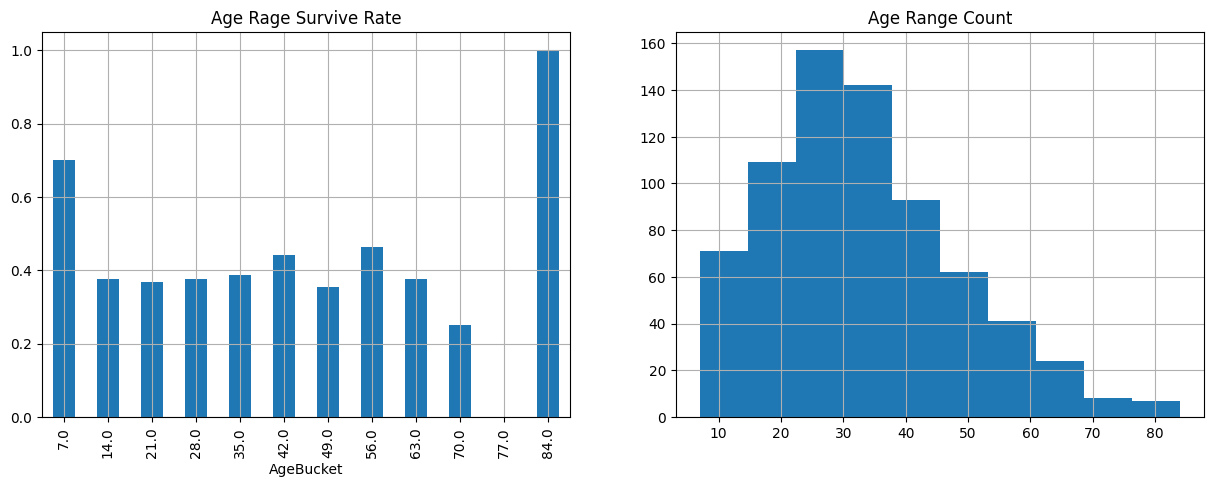

In [14]:
age_range = 7
titanic['AgeBucket'] = titanic['Age'] // age_range * age_range + age_range
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (15,5))
titanic.groupby ('AgeBucket')['Survived'].mean().plot(kind = 'bar', grid = True, ax = axes[0]).set_title ('Age Rage Survive Rate')
titanic['AgeBucket'].hist(ax = axes[1]); axes[1].set_title ('Age Range Count')
# Infant interestingly have higher surviving chance: This information will be used for splitting the Age

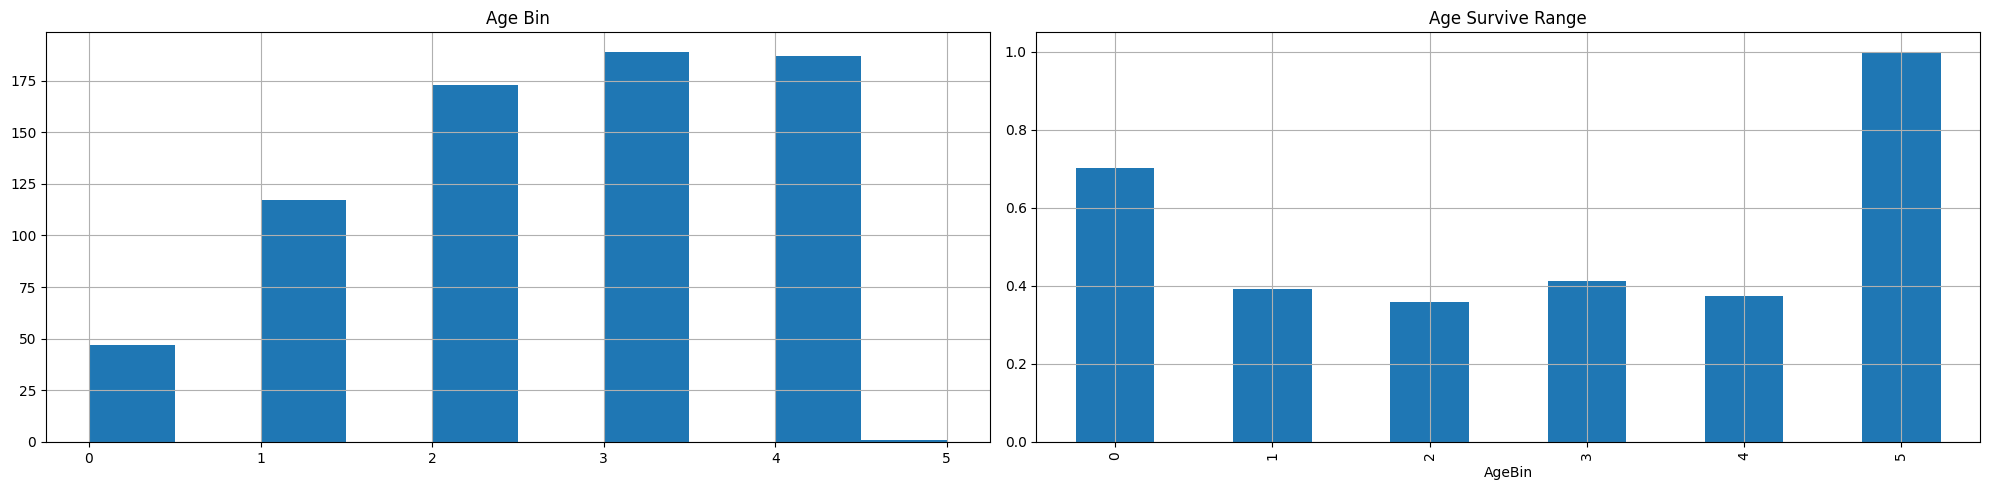

In [15]:
for df in datasets + [titanic]:
    df['AgeBin'] = pd.cut (
        df['Age'], 
        bins = [0, 7, 20, 28, 38, 80, 1000],
        labels = [0, 1, 2, 3, 4, 5],
        right = False,
    )
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
titanic['AgeBin'].hist(ax = axes[0]); axes[0].set_title ('Age Bin')
titanic.groupby('AgeBin')['Survived'].mean().plot(kind = 'bar', grid = 'True', ax = axes[1]); axes[1].set_title ('Age Survive Range')
plt.tight_layout(); plt.show()

It can be seen that group 0 has the most promising rate of surviving. Therefore, we will keep group 0 only to reduce our dimension

<Axes: xlabel='Children'>

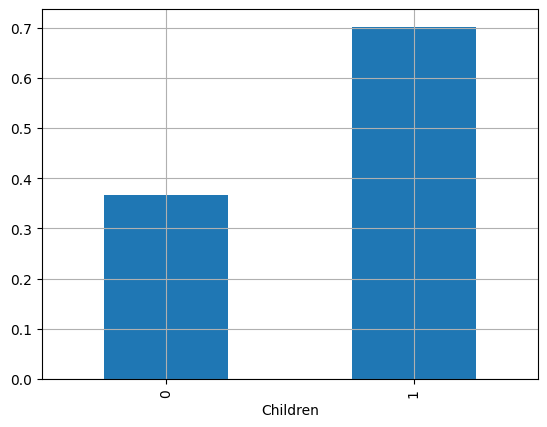

In [16]:
titanic['Children'] = (titanic['AgeBin'] == 0).astype(int)
titanic.groupby ('Children')['Survived'].mean().plot(kind = 'bar', grid = True)

In [17]:
for df in datasets:
    df['Children'] = (df['AgeBin'] == 0).astype(int)

print (f'Check null values feature Children in train and test')
print ('Train:', data['Children'].isna().any())
print ('Test:', submission['Children'].isna().any())

Check null values feature Children in train and test
Train: False
Test: False


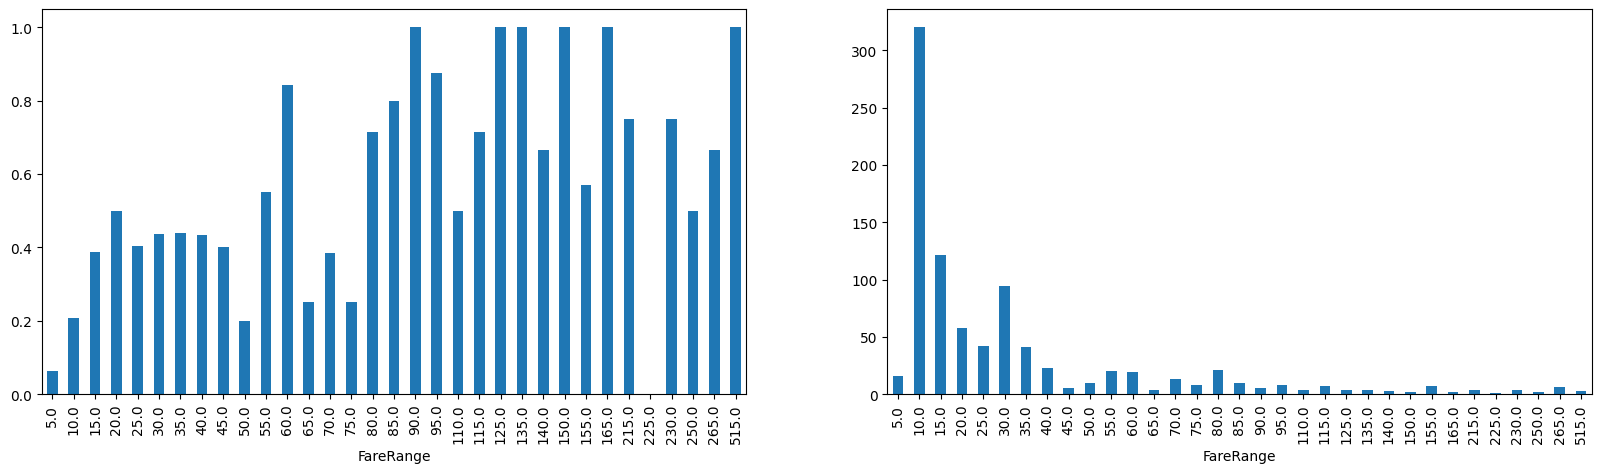

In [18]:
titanic['FareRange'] = titanic['Fare'] // 5 * 5 + 5
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
titanic.groupby('FareRange')['Survived'].mean().plot(kind = 'bar', ax = axes[0])
titanic.groupby('FareRange')['FareRange'].count().plot(kind = 'bar', ax = axes[1])
plt.show()

There is a pattern: People who pay less than 55 tend to die; People pay from 55 - 80 seems to have slightly higher chance; People spent over 80 has highest survive chance
#
Again, this will be useful to split the data

In [19]:
for df in datasets:
    df['FareRange'] = pd.cut (
        df['Fare'],
        bins = [0, 7, 15, 55 , 80, 1000],
        labels = [0, 1, 2, 3, 4],
        right = False
    )
print (titanic['Fare'].describe())
titanic['FareRange'].isna().any()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


np.False_

Text(0.5, 1.0, 'Count')

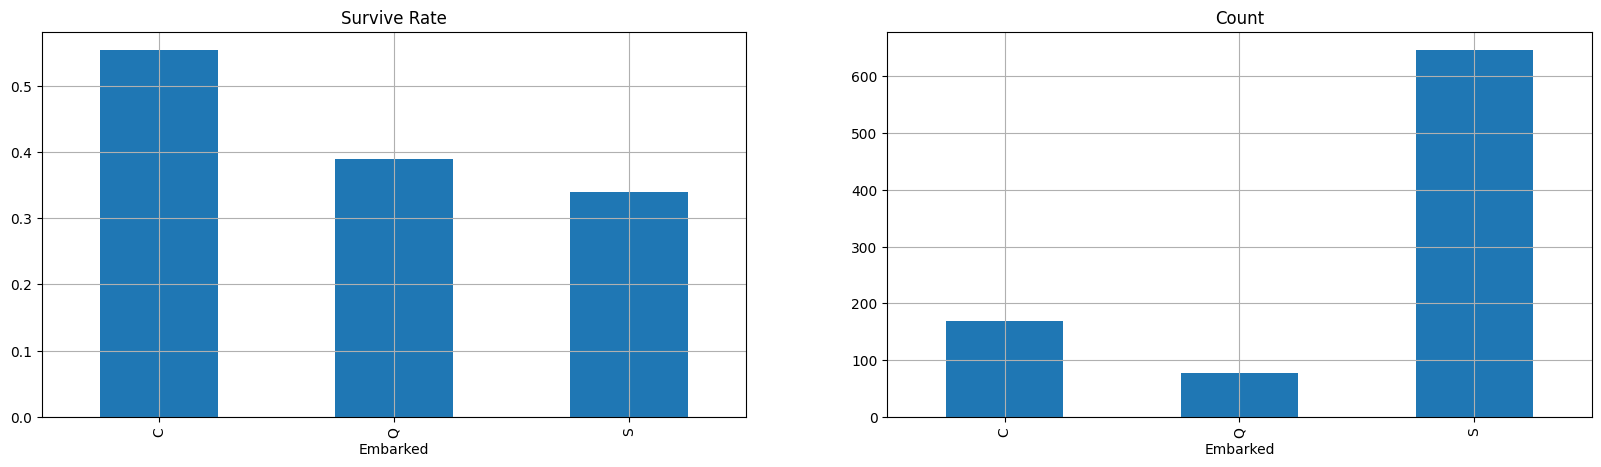

In [20]:
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
titanic.groupby('Embarked')['Survived'].mean().plot(kind = 'bar', grid = True, ax = axes[0]); axes[0].set_title ('Survive Rate')
titanic.groupby('Embarked')['Embarked'].count().plot(kind = 'bar', grid = True, ax = axes[1]); axes[1].set_title ('Count')

Interestingly, Port S was most crowded, and most people from port S didn't survive. Port C, meanwhile, had much more survivors being despite less crowded.
#
Q is the least crowded, and the survive rate is around the average rate 38%.
#
Let's dive more into such patterns

Text(0.5, 1.0, 'Correlation')

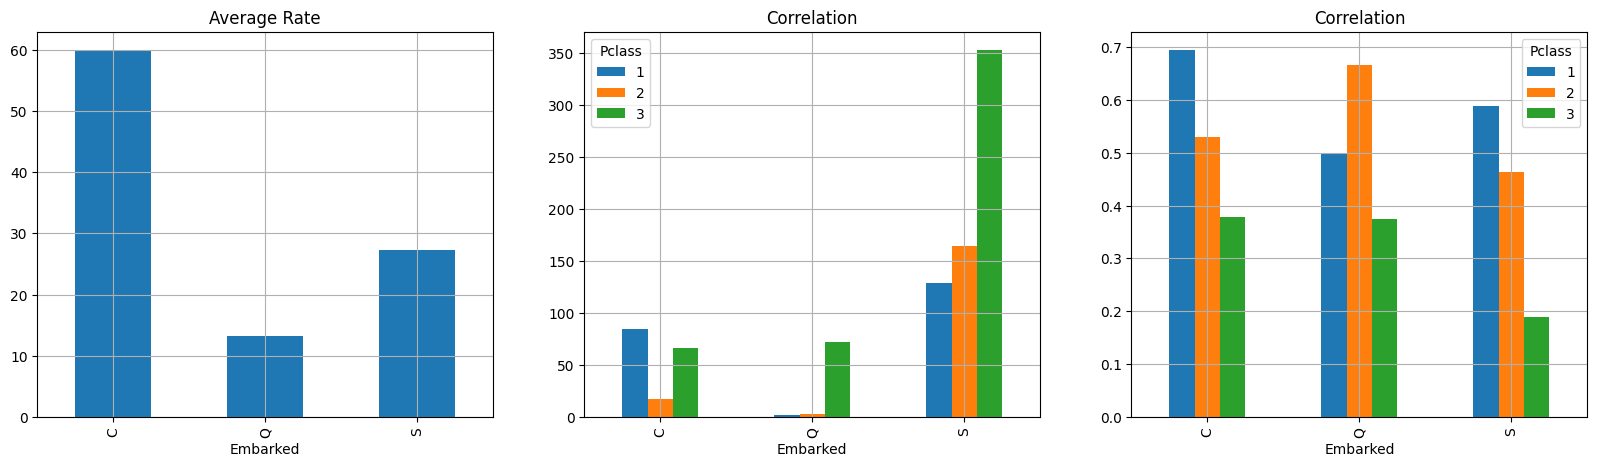

In [21]:
_, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 5))

titanic.groupby('Embarked')['Fare'].mean().plot(kind = 'bar', grid = True, ax = axes[0]); axes[0].set_title('Average Rate')

pd.pivot_table(titanic, index = 'Embarked', columns = 'Pclass', values = 'PassengerId', aggfunc='count').plot(kind = 'bar', grid = True, ax = axes[1]); axes[1].set_title ('Correlation')
pd.pivot_table(titanic, index = 'Embarked', columns = 'Pclass', values = 'Survived', aggfunc='mean').plot(kind = 'bar', grid = True, ax = axes[2]); axes[2].set_title ('Correlation')


C understandly had more survivors because there were many rich people there.
But why Q had higher surving rate than S despite the average fare fee was less ? 
#
The second and third graphs answers the question: it simply because there were significantly more passengers at port S, and most of them were 3rd class whose surviving rate was low
#
It's also worth noticing that people from class 1 and 2 always have higher chance of surviving

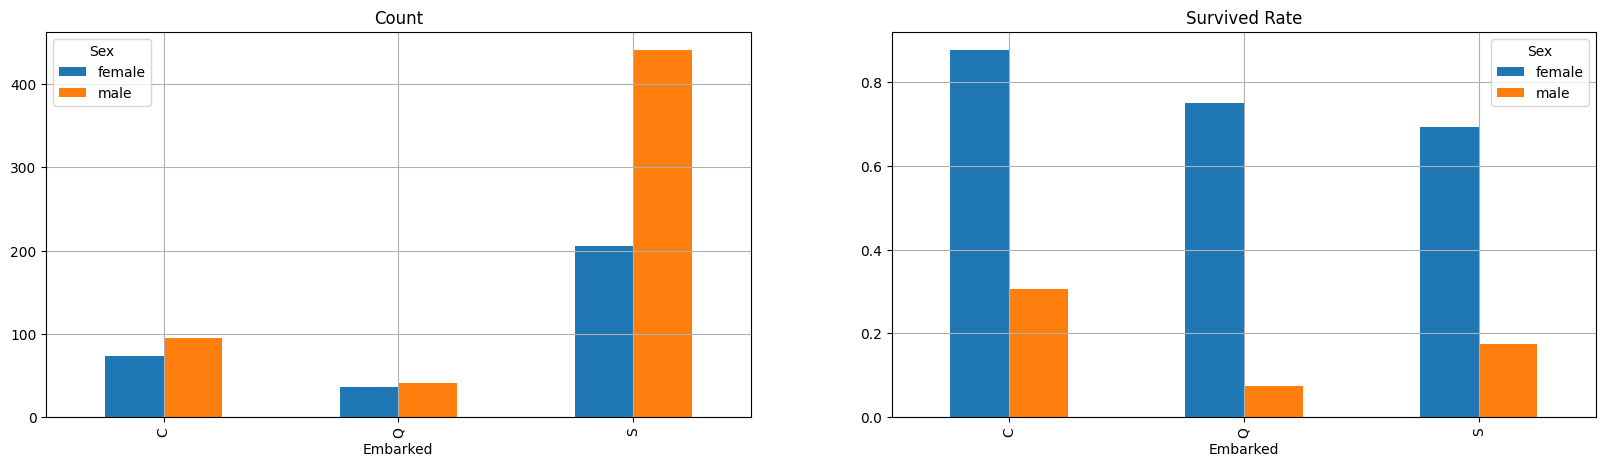

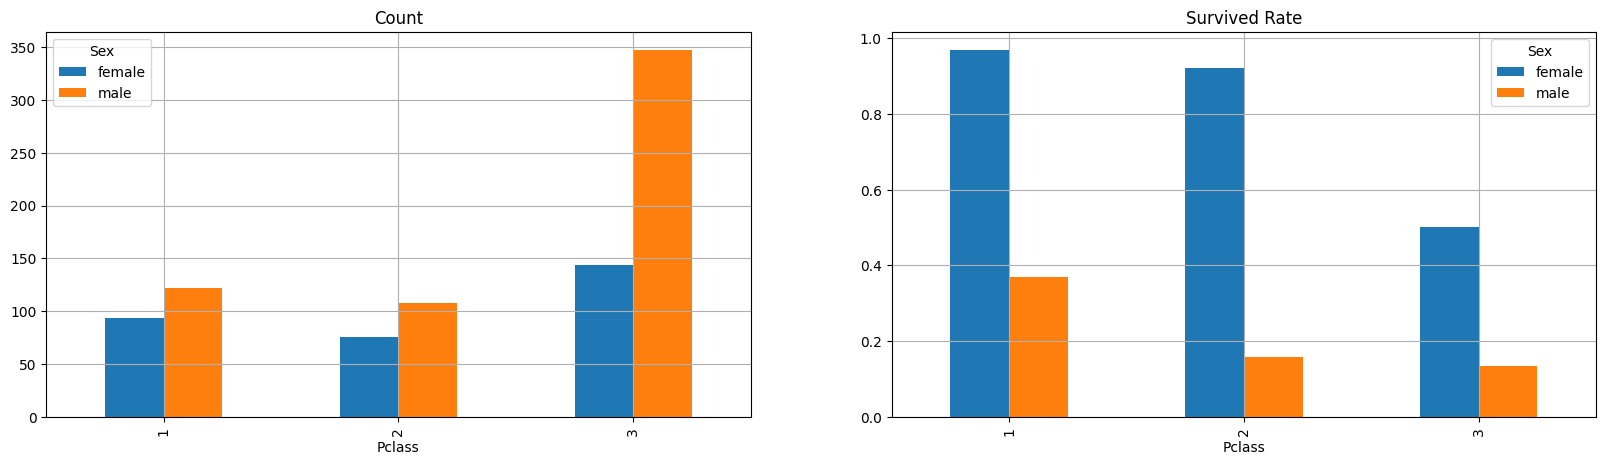

In [22]:
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
pd.pivot_table(titanic, index = 'Embarked', columns = 'Sex', values = 'PassengerId', aggfunc='count').plot(
    kind = 'bar', 
    grid = True,
    ax = axes[0],
); axes[0].set_title ('Count')
pd.pivot_table(titanic, index = 'Embarked', columns = 'Sex', values = 'Survived', aggfunc='mean').plot(
    kind = 'bar', 
    grid = True,
    ax = axes[1],
); axes[1].set_title ('Survived Rate')
plt.show()

_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
pd.pivot_table(titanic, index = 'Pclass', columns = 'Sex', values = 'PassengerId', aggfunc='count').plot(
    kind = 'bar', 
    grid = True,
    ax = axes[0],
); axes[0].set_title ('Count')
pd.pivot_table(titanic, index = 'Pclass', columns = 'Sex', values = 'Survived', aggfunc='mean').plot(
    kind = 'bar', 
    grid = True,
    ax = axes[1],
); axes[1].set_title ('Survived Rate')
plt.show()

Interestingly, female had much higher chance of surviving than male, despite the number of male passengers is often higher. 

In [23]:
print ('Number of not-null Cabin:' ,titanic['Cabin'].notna().sum())
print ('Number of unique cabins:' ,len(titanic['Cabin'].unique()))
titanic['Cabin'].dropna().head()

Number of not-null Cabin: 204
Number of unique cabins: 148


1      C85
3     C123
6      E46
10      G6
11    C103
Name: Cabin, dtype: str

Though 204 cabins are not null, 148 of them are unique. So, there's no way we can fill nan values in this feature. 
#
Thereby, I will try to extract the most out of it before dropping this feature
# 
As cabins are composed of a letter and a number, I will try to extract those information

In [24]:
cabins = all_data['Cabin'].dropna().unique().tolist()
cabin_letters = {}
for cabin in cabins:
    letters = re.findall (r"[A-Za-z]+", cabin)
    for letter in letters:
        cabin_letters[letter] = cabin_letters.get(letter, 0) + 1
print ('Cabin letters:', cabin_letters)

all_cabins = [letter for letter in cabin_letters.keys()]
rare_cabins = ['G', 'F', 'T', 'A']
common_cabins = [letter for letter in all_cabins if letter not in rare_cabins]

def has_rare_cabins (cabin):
    if str(cabin) == 'nan': return 0
    words = re.findall (r"[A-Za-z]+", cabin)
    for word in words:
        if word in rare_cabins:
            return 1
    return 0

for cabin in common_cabins:
    titanic[f'Cabin_letter_{cabin}'] = titanic['Cabin'].apply(
        lambda x: 0 if str(x) == 'nan' else 1 if cabin in x else 0
    )
titanic['Rare_cabin_letter'] = titanic['Cabin'].apply(has_rare_cabins)

Cabin letters: {'C': 61, 'E': 31, 'G': 3, 'D': 31, 'A': 20, 'B': 51, 'F': 10, 'T': 1}


As we are unsure about whether these new features will be helpful or not, Chi Squared Test will be used to verify the correlation among them and target value

In [25]:
from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score

In [26]:
results = []
for cabin in common_cabins:
    table = pd.crosstab(titanic[f'Cabin_letter_{cabin}'], titanic['Survived'])
    stat, p, dof, expected = chi2_contingency(table)
    results.append ({
        'feature': f'cabin_letter_{cabin}',
        'stat': stat,
        'p': p, 
        'dof': dof, 
        'significant': p < 0.05
    })

table = pd.crosstab(titanic['Rare_cabin_letter'], titanic['Survived'])
stat, p, dof, expected = chi2_contingency(table)
results.append ({
    'feature': 'rare_cabin',
    'stat': stat,
    'p': p,
    'dof': dof,
    'significant': p < 0.05
})
results_df = pd.DataFrame(results).sort_values('p', ascending=True)
print (f'------------------Chi2 Test-------------')
print (results_df); print()
# From the chi squared test below, rare_cabin are not very helpful, so we will not take it

print (f'--------Each Cabin Surviving Rate-------')
for cabin in common_cabins:
    print (titanic.groupby(f'Cabin_letter_{cabin}')['Survived'].mean()); print()

------------------Chi2 Test-------------
          feature       stat             p  dof  significant
3  cabin_letter_B  25.729580  3.927607e-07    1         True
1  cabin_letter_E  18.631492  1.585793e-05    1         True
2  cabin_letter_D  18.631492  1.585793e-05    1         True
0  cabin_letter_C  10.783385  1.024152e-03    1         True
4      rare_cabin   1.955179  1.620298e-01    1        False

--------Each Cabin Surviving Rate-------
Cabin_letter_C
0    0.36899
1    0.59322
Name: Survived, dtype: float64

Cabin_letter_E
0    0.369464
1    0.757576
Name: Survived, dtype: float64

Cabin_letter_D
0    0.369464
1    0.757576
Name: Survived, dtype: float64

Cabin_letter_B
0    0.363744
1    0.744681
Name: Survived, dtype: float64



Fortunately, most of the information about the deck of the cabins are nice, people in these common cabins are more prone to surviving. 
#
In the future we may have to drop some features, so I will create a function for this
#
Also, we will experiment some more features, so we will need a function for chi2 test as well

In [27]:
for df in datasets:
    for cabin in common_cabins:
        titanic[f'Cabin_letter_{cabin}'] = titanic['Cabin'].apply(
            lambda x: 0 if str(x) == 'nan' else 1 if cabin in x else 0
        )

In [28]:
def drop_features (df, features: list):
    if not isinstance(features, list): features = [features]
    for feature in features:
        if feature in df.columns:
            df.drop (feature, axis = 1, inplace = True)

def chi_squared_test (df, features: list, target: str):
    if not isinstance(features, list): features = [features]
    results = []
    for feature in features:
        table = pd.crosstab(df[feature], df[target])
        stat, p, dof, _ = chi2_contingency(table)
        results.append ({
            'feature': feature,
            'stat': stat,
            'p': p,
            'dof': dof,
            'significant': p < 0.05,
        })
    results_df = pd.DataFrame(results).sort_values('p', ascending = True)
    return results_df

I will try to experiment the same thing with cabin_numbers

In [29]:
cabin_numbers = {}
for cabin in cabins:
    numbers = re.findall (r"[\b\d\b]+", cabin)
    for letter in numbers:
        cabin_numbers[letter] = cabin_numbers.get (letter, 0) + 1
print (f'Number of unique number: {len(cabin_numbers)}')
print (f'Cabin numbers: {cabin_numbers}')

Number of unique number: 110
Cabin numbers: {'85': 1, '123': 1, '46': 4, '6': 4, '103': 1, '56': 2, '23': 2, '25': 2, '27': 1, '78': 2, '33': 3, '30': 3, '52': 3, '28': 3, '83': 1, '73': 2, '31': 3, '5': 2, '10': 4, '12': 2, '26': 4, '110': 1, '58': 2, '60': 2, '101': 3, '69': 2, '47': 2, '86': 2, '2': 2, '19': 3, '7': 3, '49': 4, '4': 2, '32': 2, '80': 2, '36': 4, '15': 1, '93': 1, '35': 2, '87': 1, '77': 2, '67': 1, '94': 1, '125': 1, '99': 1, '118': 1, '22': 3, '106': 1, '65': 1, '54': 2, '57': 3, '59': 1, '63': 3, '66': 1, '34': 3, '18': 2, '124': 1, '91': 1, '40': 2, '128': 1, '37': 2, '50': 4, '82': 2, '96': 1, '98': 1, '44': 1, '104': 1, '111': 1, '92': 1, '38': 4, '21': 2, '14': 1, '20': 3, '79': 1, '95': 1, '39': 3, '70': 1, '16': 1, '68': 2, '41': 2, '9': 2, '48': 1, '126': 1, '71': 1, '51': 2, '53': 2, '55': 2, '62': 1, '64': 1, '24': 3, '90': 1, '45': 4, '8': 1, '121': 1, '11': 3, '3': 1, '84': 1, '17': 2, '102': 1, '42': 1, '148': 1, '61': 1, '43': 1, '130': 1, '132': 1, '

As there are upto 101 unique cabin numbers, this is not a helpful information

In [30]:
print (f'--------Ticket-----------')
unique_count = len(titanic['Ticket'].unique())
percent = unique_count / len(titanic['Ticket'].dropna()) * 100
print (f'Unique values: {unique_count}')
print (f'Unique values proportion: {percent}')

print (f'--------Cabin-----------')
unique_count = len(titanic['Cabin'].unique())
percent = unique_count / len(titanic['Cabin'].dropna()) * 100
print (f'Unique values: {unique_count}')
print (f'Unique values proportion: {percent}')

titanic['Ticket'].dropna().head()

--------Ticket-----------
Unique values: 681
Unique values proportion: 76.43097643097643
--------Cabin-----------
Unique values: 148
Unique values proportion: 72.54901960784314


0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: str

Same case for Ticket, where the number of unique values is basically too high, making it a high-cardinalilty feature => Have to drop
#
Before dropping, we will extract information the same way we did on Cabin
#
Also notice that there are around 25 - 28% of tickets and cabins that are not unique. This could be some information. We will take a look later

In [31]:
titanic['Ticket'] = titanic['Ticket'].apply(
    lambda x: re.sub (r'[.,/\\]', '' , x)
)
print ('-------Ticket format-------')
print (titanic['Ticket'].head());print()

tickets = titanic['Ticket'].unique().tolist()
ticket_letters = {}
for ticket in tickets:
    letters = re.findall (r"[A-Za-z]+", ticket)
    for letter in letters:
        ticket_letters[letter] = ticket_letters.get (letter, 0) + 1
common_letter = [letter for letter in ticket_letters.keys() if ticket_letters[letter] > 30]
common_letter

titanic['Has_PC_ticket'] = titanic['Ticket'].apply(
    lambda x: 0 if str(x) == 'nan' else 1 if 'PC' in x else 0
)
print ('-------Has PC Ticket Survive Rate-------')
print ('PC survive rate:', titanic.groupby ('Has_PC_ticket')['Survived'].mean()); print()
chi_squared_test(titanic, 'Has_PC_ticket', 'Survived')
# The p value of PC ticket does not seem to correlate with surviving rate, so we won't keep it

-------Ticket format-------
0          A5 21171
1          PC 17599
2    STONO2 3101282
3            113803
4            373450
Name: Ticket, dtype: str

-------Has PC Ticket Survive Rate-------
PC survive rate: Has_PC_ticket
0    0.364621
1    0.650000
Name: Survived, dtype: float64



,feature,stat,p,dof,significant
0,Has_PC_ticket,18.081981,0.000021,1,True


This code will create features the number of similar tickets to one ticket
#
Cramer and Mutual information will be used to measure whether this relationship is highly correlated to either Parch, SibSp or both

In [32]:
# Feature shows for one person, how many other people having the same ticket as theirs
titanic['Same_ticket'] = titanic['Ticket'].apply(
    lambda x: len (titanic[titanic['Ticket'] == x]) - 1
)

def mf_test (x, y): 
    mf = mutual_info_score(x, y)
    hx = -np.sum (np.bincount(x) / len(x) * np.log2(np.bincount(x) / len(x) + 1e-10))
    hy = -np.sum (np.bincount(y) / len(y) * np.log2(np.bincount(y) / len(y) + 1e-10))
    normal = mf / min (hx, hy)
    return normal
def cramers(x, y):
    table = pd.crosstab(x, y)
    stat, p, dof, _ = chi2_contingency(table)
    n = table.sum().sum()
    min_dim = min (table.shape) - 1
    return np.sqrt (stat / (n * min_dim)) if min_dim > 0 else 0 

mf_Parch = mf_test(titanic['Same_ticket'], titanic['Parch'])
cramers_Parch = cramers(titanic['Same_ticket'], titanic['Parch'])
print (f'------Parch-------')
print ('mf score', mf_Parch)
print ('cramer scores: ', cramers_Parch)

mf_SibSp = mf_test(titanic['Same_ticket'], titanic['SibSp'])
cramers_SibSp = cramers(titanic['Same_ticket'], titanic['SibSp'])
print (f'------SibSp-------')
print ('mf score', mf_SibSp)
print ('cramer scores: ', cramers_SibSp)

titanic['Accompany'] = titanic['SibSp'] + titanic['Parch']
mf_Accompany = mf_test(titanic['Same_ticket'], titanic['Accompany'])
cramers_Accompany = cramers(titanic['Same_ticket'], titanic['Accompany'])
print (f'------Accompany-------')
print ('mf score', mf_Accompany)
print ('cramer scores: ', cramers_Accompany)

print (f'------Survived-------')
print (f'{chi_squared_test(titanic, 'Same_ticket', 'Survived')}')


------Parch-------
mf score 0.1958568746962084
cramer scores:  0.32542733137089275
------SibSp-------
mf score 0.20801615227027573
cramer scores:  0.4670529839451778
------Accompany-------
mf score 0.2522324930598861
cramer scores:  0.5836210994127533
------Survived-------
       feature       stat             p  dof  significant
0  Same_ticket  94.131345  4.192434e-18    6         True


In [33]:
# Feature shows for one person, how many other people having the same Cabin as theirs
titanic['Same_Cabin'] = titanic['Cabin'].apply(
    lambda x: 0 if str(x) == 'nan' else len (titanic[titanic['Cabin'] == x]) - 1
)

mf_Parch = mf_test(titanic['Same_Cabin'], titanic['Parch'])
cramers_Parch = cramers(titanic['Same_Cabin'], titanic['Parch'])

print (f'------Parch-------')
print ('mf score', mf_Parch)
print ('cramer scores: ', cramers_Parch)

mf_SibSp = mf_test(titanic['Same_Cabin'], titanic['SibSp'])
cramers_SibSp = cramers(titanic['Same_Cabin'], titanic['SibSp'])
print (f'------SibSp-------')
print ('mf score', mf_SibSp)
print ('cramer scores: ', cramers_SibSp)

titanic['Accompany'] = titanic['SibSp'] + titanic['Parch']
mf_Accompany = mf_test(titanic['Same_Cabin'], titanic['Accompany'])
cramers_Accompany = cramers(titanic['Same_Cabin'], titanic['Accompany'])
print (f'------Accompany-------')
print ('mf score', mf_Accompany)
print ('cramer scores: ', cramers_Accompany)

print (f'------Survived-------')
print (f'{chi_squared_test(titanic, 'Same_Cabin', 'Survived')}')


------Parch-------
mf score 0.05756660506374886
cramer scores:  0.19243627468322044
------SibSp-------
mf score 0.05353463621547131
cramer scores:  0.1784068571770103
------Accompany-------
mf score 0.11172159964689182
cramer scores:  0.26796773100212684
------Survived-------
      feature       stat             p  dof  significant
0  Same_Cabin  69.243789  6.196894e-15    3         True


In [34]:
def has_companion (ticket, cabin, name):
    ticket = str(ticket)
    cabin = str(cabin)
    df = titanic[((titanic['Ticket'] == ticket) | (titanic['Cabin'] == cabin) & (titanic['Name'] != name))]
    return len(df)

titanic['Companion'] = titanic.apply(
    lambda row: has_companion(row['Ticket'], row['Cabin'], row['Name']), axis = 1
)

mf_Parch = mf_test(titanic['Companion'], titanic['Parch'])
cramers_Parch = cramers(titanic['Companion'], titanic['Parch'])

print (f'------Parch-------')
print ('mf score', mf_Parch)
print ('cramer scores: ', cramers_Parch)

mf_SibSp = mf_test(titanic['Companion'], titanic['SibSp'])
cramers_SibSp = cramers(titanic['Companion'], titanic['SibSp'])
print (f'------SibSp-------')
print ('mf score', mf_SibSp)
print ('cramer scores: ', cramers_SibSp)

titanic['Accompany'] = titanic['SibSp'] + titanic['Parch']
mf_Accompany = mf_test(titanic['Companion'], titanic['Accompany'])
cramers_Accompany = cramers(titanic['Companion'], titanic['Accompany'])
print (f'------Accompany-------')
print ('mf score', mf_Accompany)
print ('cramer scores: ', cramers_Accompany)

print (f'------Survived-------')
print (f'{chi_squared_test(titanic, 'Companion', 'Survived')}')

------Parch-------
mf score 0.18551304017925715
cramer scores:  0.3166163005807283
------SibSp-------
mf score 0.19375870128278322
cramer scores:  0.45710756176909967
------Accompany-------
mf score 0.22317910425733564
cramer scores:  0.5686303999013567
------Survived-------
     feature        stat             p  dof  significant
0  Companion  111.777897  8.647648e-22    6         True


Out of same_cabin same_ticket and companion, companion feature has the highest correlation towards Survived. Thereby, we will keep this feature

In [35]:
for df in datasets:
    df['Companion'] = df.apply(
        lambda row: has_companion(row['Ticket'], row['Cabin'], row['Name']),
        axis = 1,
    )

Because one person may go with other people and pay for them. I want to know what is the actual price of a ticket

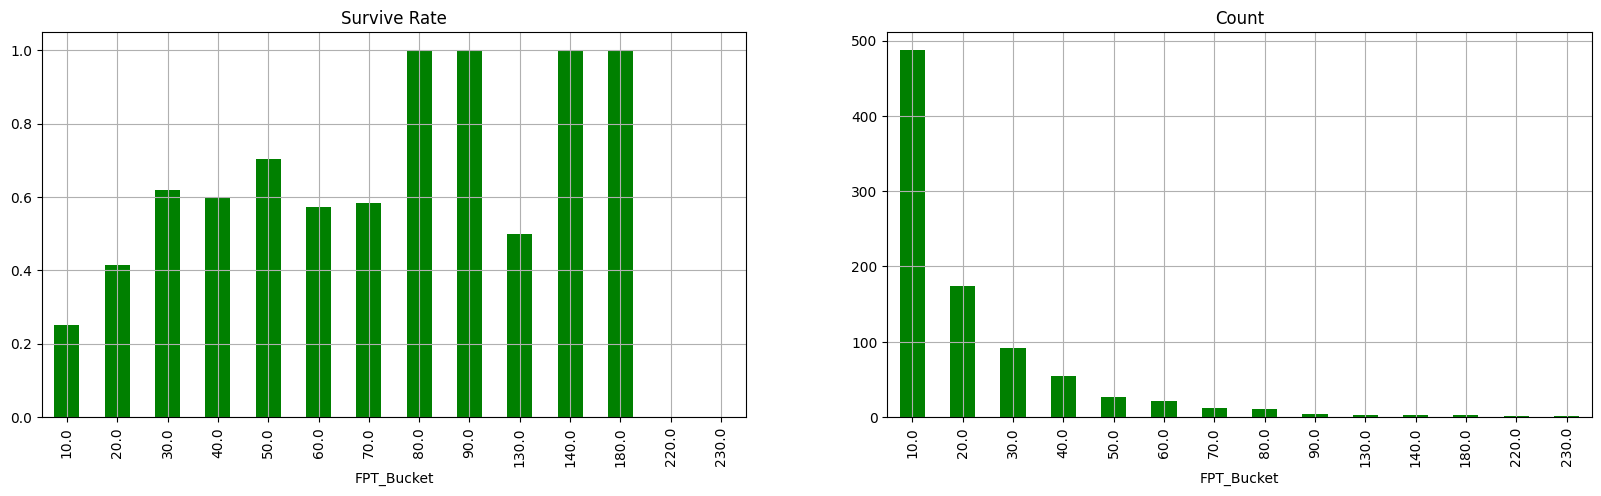

count    891.000000
mean      17.788989
std       21.218157
min        0.000000
25%        7.762500
50%        8.850000
75%       24.288200
max      221.779200
Name: Fare_per_ticket, dtype: float64


In [36]:
def calculate_fare_per_ticket(fare, number):
    if str(fare) == 'nan' or str(number) == 'nan': return np.nan
    return fare / (number + 1)
titanic['Fare_per_ticket'] = titanic.apply(
    lambda row: calculate_fare_per_ticket(row['Fare'], row['Same_ticket']),
    axis = 1,
)

fare_range = 10
titanic['Fare_per_ticket'].describe()
titanic['FPT_Bucket'] = titanic['Fare_per_ticket'] // fare_range * fare_range + fare_range

_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
titanic.groupby('FPT_Bucket')['Survived'].mean().plot(kind = 'bar', grid = True, ax = axes[0], color = 'green'); axes[0].set_title('Survive Rate')
titanic.groupby('FPT_Bucket')['FPT_Bucket'].count().plot(kind = 'bar', grid = True, ax = axes[1], color = 'green'); axes[1].set_title('Count')
plt.show()
print (titanic['Fare_per_ticket'].describe())

Apparently, people paid over 70 per ticket had significantly higher chance of surving. This together with 25th range percentile will be used to split the feature

C:\Users\alexh\AppData\Local\Temp\ipykernel_7308\2305848923.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  titanic.groupby('Fare/ticket_Range')['Survived'].mean().plot(kind = 'bar', grid = True, color = 'green', ax = axes[0]); plt.legend()


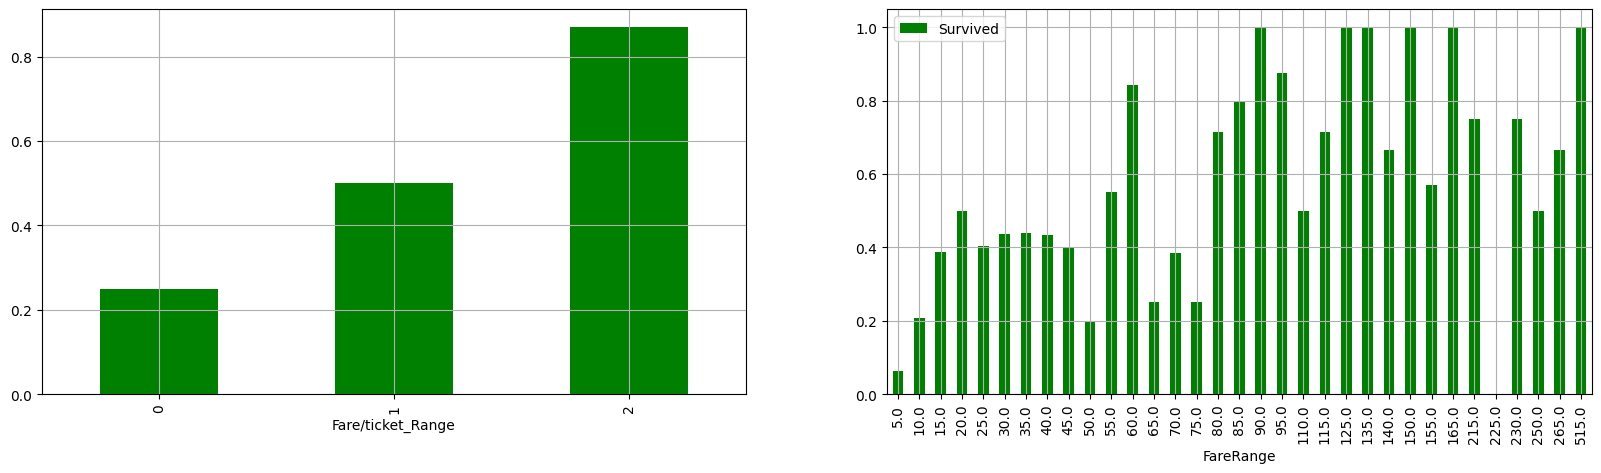

C:\Users\alexh\AppData\Local\Temp\ipykernel_7308\2305848923.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  titanic.groupby('Fare/ticket_Range')['Fare/ticket_Range'].count().plot(kind = 'bar', grid = True, color = 'green', ax = axes[0]); plt.legend()


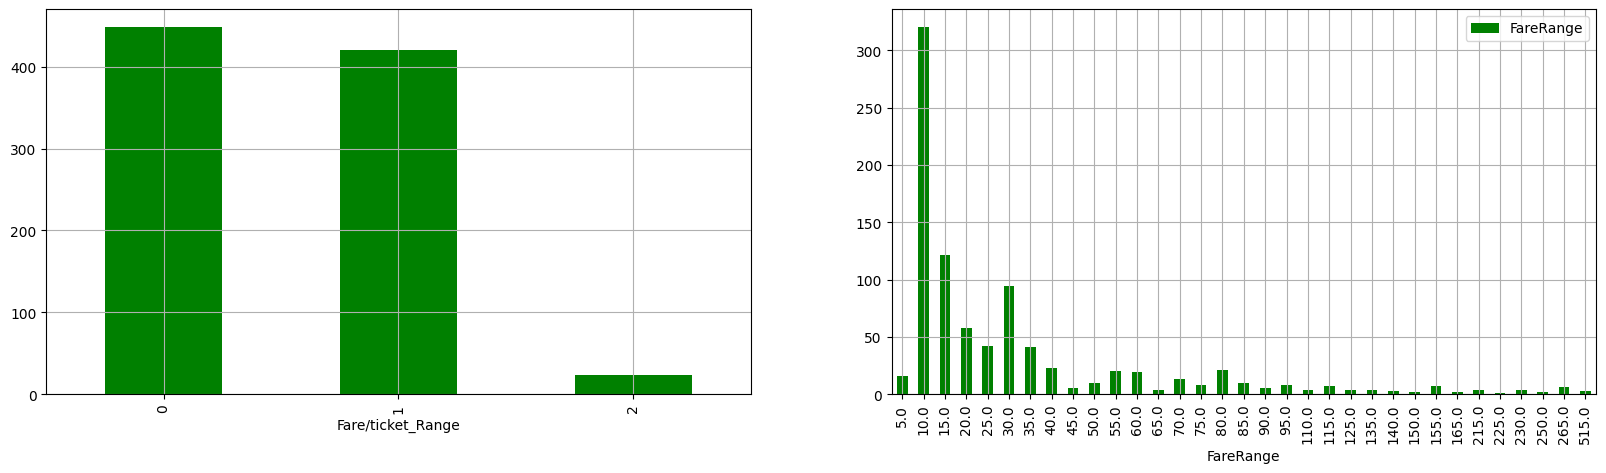

Cramer score: 0.7723270051714962
Mf score: 0.3513693038042789


C:\Users\alexh\AppData\Local\Temp\ipykernel_7308\2031563620.py:9: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  hy = -np.sum (np.bincount(y) / len(y) * np.log2(np.bincount(y) / len(y) + 1e-10))


In [37]:
titanic['Fare/ticket_Range'] = pd.cut (titanic['Fare_per_ticket'], bins = [0, 9, 70, 500], labels = [0, 1, 2], right=False)
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
titanic.groupby('Fare/ticket_Range')['Survived'].mean().plot(kind = 'bar', grid = True, color = 'green', ax = axes[0]); plt.legend()
titanic.groupby('FareRange')['Survived'].mean().plot(kind = 'bar', grid = True, color = 'green', ax = axes[1]); plt.legend()
plt.show()

_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
titanic.groupby('Fare/ticket_Range')['Fare/ticket_Range'].count().plot(kind = 'bar', grid = True, color = 'green', ax = axes[0]); plt.legend()
titanic.groupby('FareRange')['FareRange'].count().plot(kind = 'bar', grid = True, color = 'green', ax = axes[1]); plt.legend()
plt.show()

cramer_score = cramers(titanic['Fare/ticket_Range'], titanic['FareRange']); print (f'Cramer score: {cramer_score}')
mf_score = mf_test(titanic['Fare/ticket_Range'], titanic['FareRange']); print (f'Mf score: {mf_score}')

The cramer and mutual information score shows that this feature is not so highly correlated with Fare so we can keep it

In [38]:
for df in datasets:
    df['Same_ticket'] = df['Ticket'].apply(
        lambda x: len (df[df['Ticket'] == x]) - 1
    )
    df['Fare_per_ticket'] = df.apply(
        lambda row: calculate_fare_per_ticket(row['Fare'], row['Same_ticket']),
        axis = 1,
    )
    fare_range 
    df['Fare/ticket_Range'] = pd.cut (df['Fare_per_ticket'], bins = [0, 9, 70, 1000], labels = [0, 1, 2], right=False)
    df.drop ('Fare_per_ticket', axis = 1, inplace = True)
    df.drop ('Same_ticket', axis = 1, inplace = True)

------Correlation between SibSp and Parch-------
Mf score 0.12529897203802384
Cramer 0.25281134828611734
------Parch, SibSp and Survived--------
  feature       stat         p  dof  significant
0   SibSp  37.271793  0.000002    6         True
1   Parch  27.925784  0.000097    6         True


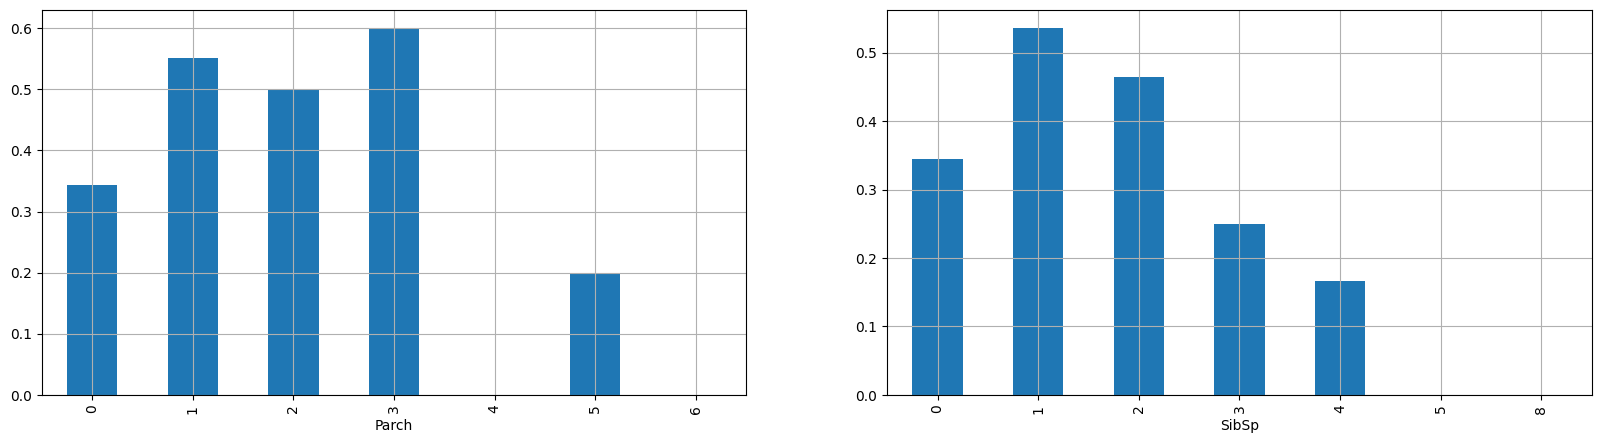

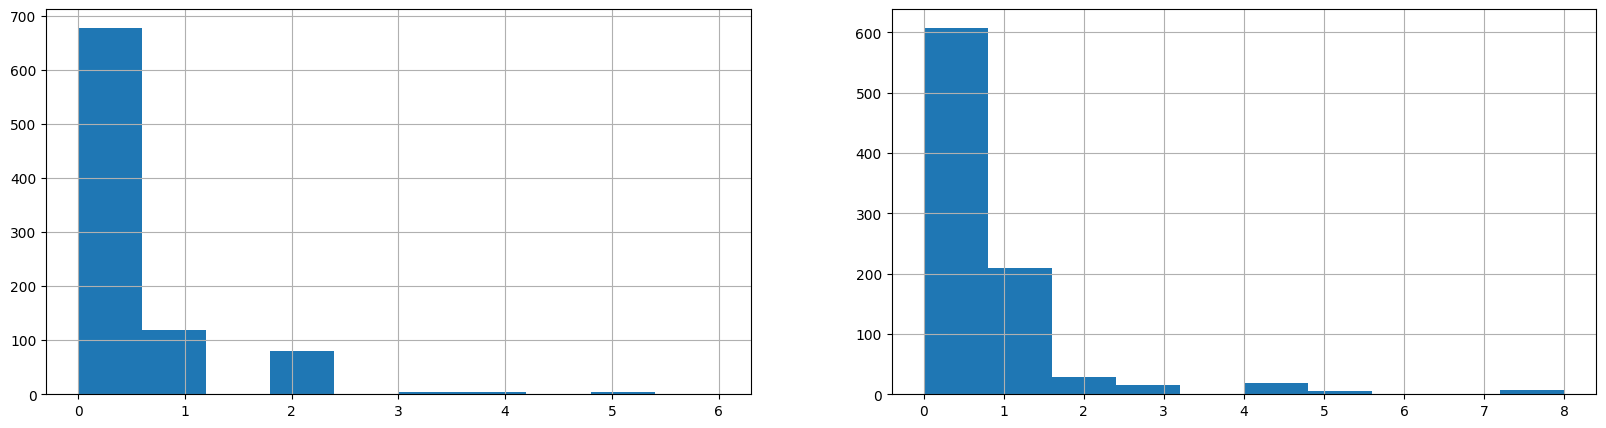

In [39]:
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
titanic.groupby('Parch')['Survived'].mean().plot (kind = 'bar', grid = True, ax = axes[0])
titanic.groupby('SibSp')['Survived'].mean().plot (kind = 'bar', grid = True, ax = axes[1])

_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 5))
titanic['Parch'].hist(ax = axes[0])
titanic['SibSp'].hist(ax = axes[1])

print (f'------Correlation between SibSp and Parch-------')
mf_score = mf_test(titanic['Parch'], titanic['SibSp']); print (f'Mf score', mf_score)
cramer_score = cramers(titanic['Parch'], titanic['SibSp']); print (f'Cramer', cramer_score)
print (f'------Parch, SibSp and Survived--------')
chi2 = chi_squared_test(titanic, ['SibSp', 'Parch'], 'Survived')
print (chi2)

Parch and SibSp does not seem to correlate well with Survived, so we will have to generate new features from these. Then drop these two

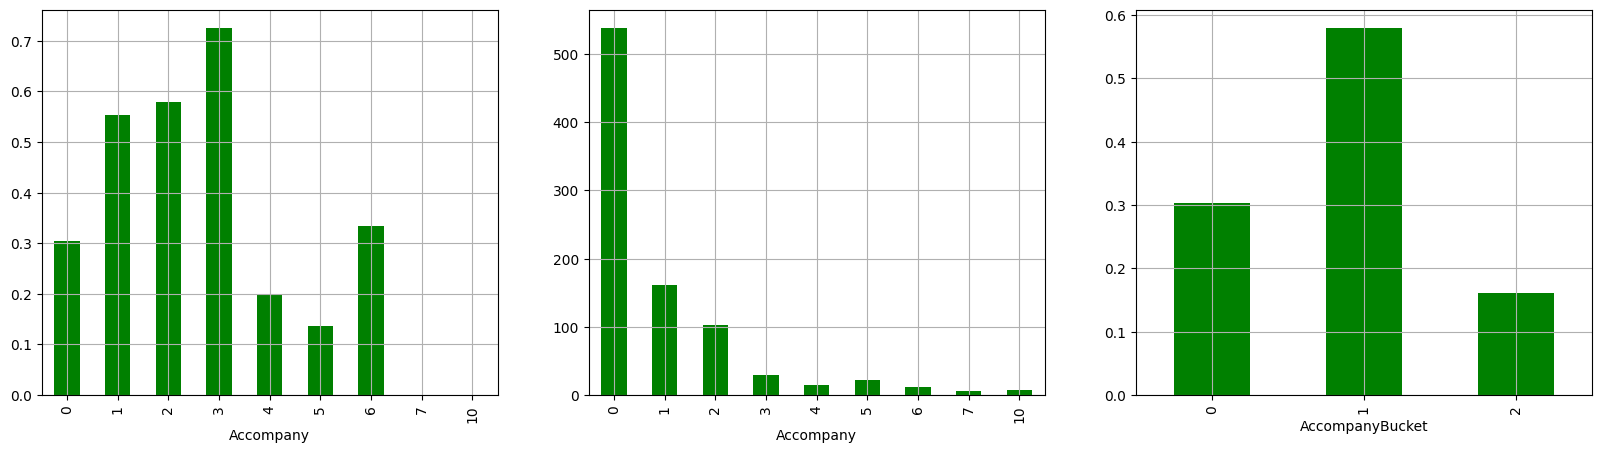

           feature       stat             p  dof  significant
0  AccompanyBucket  74.537249  6.522920e-17    2         True


In [40]:
_, axes = plt.subplots (nrows = 1, ncols = 3, figsize = (20,5))
titanic.groupby('Accompany')['Survived'].mean().plot(kind = 'bar', color = 'green', grid = True, ax = axes[0])
titanic.groupby('Accompany')['Accompany'].count().plot(kind = 'bar', color = 'green', grid = True, ax = axes[1])
# The graph 2 shows that the surviving rate reaches peak when there are around 1-3 accompanies, then drops again 

def map_accompany(accompany): 
    if accompany == 0: return 0
    elif accompany > 0 and accompany < 4: return 1
    else: return 2
titanic['AccompanyBucket'] = titanic['Accompany'].apply(map_accompany)
titanic.groupby('AccompanyBucket')['Survived'].mean().plot(kind = 'bar', color = 'green', grid = True, ax = axes[2])
plt.show()

chi_score = chi_squared_test(titanic, 'AccompanyBucket', 'Survived')
print (chi_score)

Apparently, people at group one (1 - 3 acompanies) had the highest surviving chance, followed by Alone and Crowded family group

In [41]:
for df in datasets:
    df['Accompany'] = df['SibSp'] + df['Parch']
    df['AccompanyBucket'] = df['Accompany'].apply(map_accompany)
    df.drop ('Accompany', axis = 1, inplace = True)

In [42]:
titanic['Name'].dropna().head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: str

Names are often included with titles in the format (, title.)
#
Let's take a look at all the existing titles 

In [43]:
all_data['Title'] = all_data['Name'].apply(
    lambda x: np.nan if str(x) =='nan' else x.split (',')[1].split('.')[0].strip()
)
titles = all_data['Title'].unique().tolist()
titles

['Mr',
 'Mrs',
 'Miss',
 'Master',
 'Don',
 'Rev',
 'Dr',
 'Mme',
 'Ms',
 'Major',
 'Lady',
 'Sir',
 'Mlle',
 'Col',
 'Capt',
 'the Countess',
 'Jonkheer',
 'Dona']

['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms', 'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess', 'Jonkheer', 'Dona']


<Axes: xlabel='Title'>

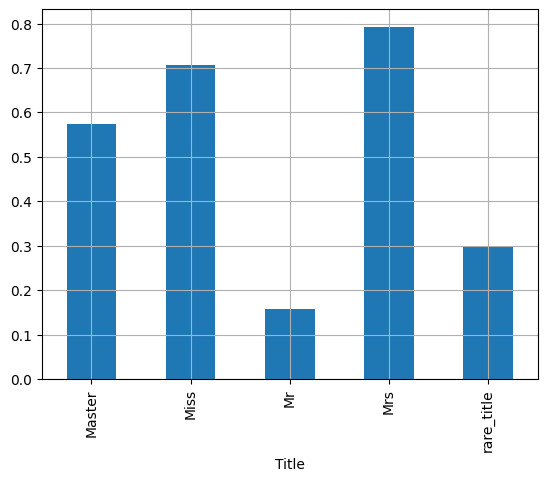

In [44]:
print (titles)

title_map = {
    'Mlle': 'Miss',
    'Don': 'Mr', 
    'Mme': 'Miss',
    'Ms': 'Miss',
    'Lady': 'Miss',
    'Sir': 'Mr',
    'Ms': 'Miss',
}
titanic['Title'] = titanic['Name'].apply(
    lambda x: np.nan if str(x) == 'nan' else x.split (',')[1].split('.')[0].strip()
)
titanic['Title'] = titanic['Title'].apply(lambda x: title_map.get(x, x))
titles_count = titanic['Title'].value_counts()
common_titles = titles_count[titles_count >= 30].index.tolist()
rare_titles = [Title for Title in titles if Title not in common_titles]

titanic['Title'] = titanic['Title'].apply(
    lambda x: 'rare_title' if x in rare_titles else x
)
titanic.groupby('Title')['Survived'].mean().plot(kind = 'bar', grid = True)

Let's see how are these titles correlated with the target value by using Chi Squared Test

In [45]:
title_features = []
for title in common_titles:
    titanic[f'Title_{title}'] = titanic['Title'].apply(
        lambda x: 1 if title in x else 0
    )
    title_features.append (f'Title_{title}')
titanic['Title_rare'] = titanic['Title'].apply(
    lambda x: 1 if x in rare_titles else 0
)
title_features.append ('Title_rare')
chi_squared_test(titanic, title_features, 'Survived')

,feature,stat,p,dof,significant
0,Title_Mr,102.205847,5.004199e-24,1,True
1,Title_Miss,102.068637,5.363097e-24,1,True
2,Title_Mrs,100.421346,1.231933e-23,1,True
3,Title_Master,5.652331,1.743218e-02,1,True
4,Title_rare,0.000000,1.000000e+00,0,False


As can be seen, Rare titles barely have any relationship with Target Value, so it's better to map these features to 'Mr', 'Mrs', 'Ms', and 'Master'

In [46]:
for df in datasets + [titanic]:
    title_map = {
        'Mr': 'Mr',
        'Mrs': 'Mrs',
        'Miss': 'Miss',
        'Master': 'Master',
        'Don': 'Miss',
        'Rev': 'Mr',
        'Dr': 'Profession',
        'Mme': 'Mrs',
        'Ms': 'Miss',
        'Major': 'Mr',
        'Lady': 'Miss',
        'Sir': 'Mr',
        'Mlle': 'Miss',
        'Col': 'Mr',
        'Capt': 'Mr',
        'the Countess': 'Miss',
        'Jonkheer': 'Miss',
        'Dona': 'Miss',
    }    
    df['Title'] = df['Name'].apply(
        lambda x: np.nan if str(x) == 'nan' else x.split(',')[1].split('.')[0].strip()
    )
    df['Title'] = df['Title'].apply(lambda x: title_map.get (x, x))
    for title in ['Mr', 'Mrs', 'Miss', 'Master']:
        df[f'Title_{title}'] = df['Title'].apply(
            lambda x: 1 if title in x else 0
        )
title_features = ['Title_Mr', 'Title_Miss', 'Title_Mrs', 'Title_Master']    
chi_squared_test(titanic, title_features, 'Survived')

,feature,stat,p,dof,significant
0,Title_Mr,109.123221,1.525044e-25,1,True
2,Title_Mrs,102.202699,5.012157e-24,1,True
1,Title_Miss,98.689361,2.953848e-23,1,True
3,Title_Master,5.652331,1.743218e-02,1,True


Now it can be seen that all titles are highly correlated with target value

In [47]:
print (data.columns[data.isna().any()]); print()
data.info()

Index(['Age', 'Cabin', 'AgeBin'], dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   PassengerId        891 non-null    int64   
 1   Survived           891 non-null    int64   
 2   Pclass             891 non-null    int64   
 3   Name               891 non-null    str     
 4   Sex                891 non-null    str     
 5   Age                714 non-null    float64 
 6   SibSp              891 non-null    int64   
 7   Parch              891 non-null    int64   
 8   Ticket             891 non-null    str     
 9   Fare               891 non-null    float64 
 10  Cabin              204 non-null    str     
 11  Embarked           891 non-null    str     
 12  AgeBin             714 non-null    category
 13  Children           891 non-null    int64   
 14  FareRange          891 non-null    category
 15  Companion          8

As can be seen, we are having two tasks:
* 1/ Encode Embarked feature
* 2/ Fill the AgeBin value
* 3/ Convert category data type to int

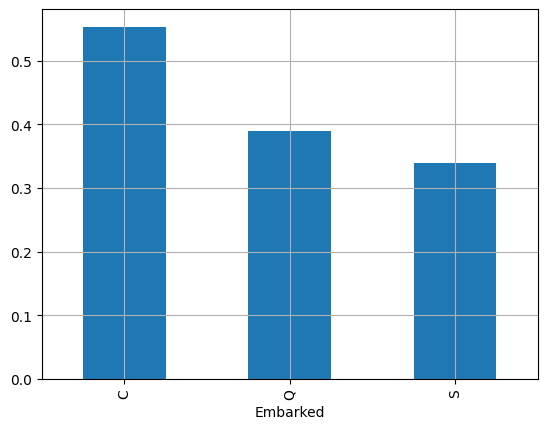

In [48]:
titanic.groupby('Embarked')['Survived'].mean().plot(kind = 'bar', grid = True)
plt.show()

Similar to title, we will ordinally encode Embarked based on its surviving rate correlation

In [49]:
for df in datasets + [titanic]:
    ports = ['S', 'Q', 'C']
    for port in ports:
        df[f'Embarked_{port}'] = df['Embarked'].apply(
            lambda x: np.nan if str(x) == 'nan' else 1 if x == port else 0 if x != port else x
        )
for port in ['C', 'Q', 'S']: 
    print (titanic[f'Embarked_{port}'].value_counts())

Embarked_C
0    723
1    168
Name: count, dtype: int64
Embarked_Q
0    814
1     77
Name: count, dtype: int64
Embarked_S
1    646
0    245
Name: count, dtype: int64


<Axes: >

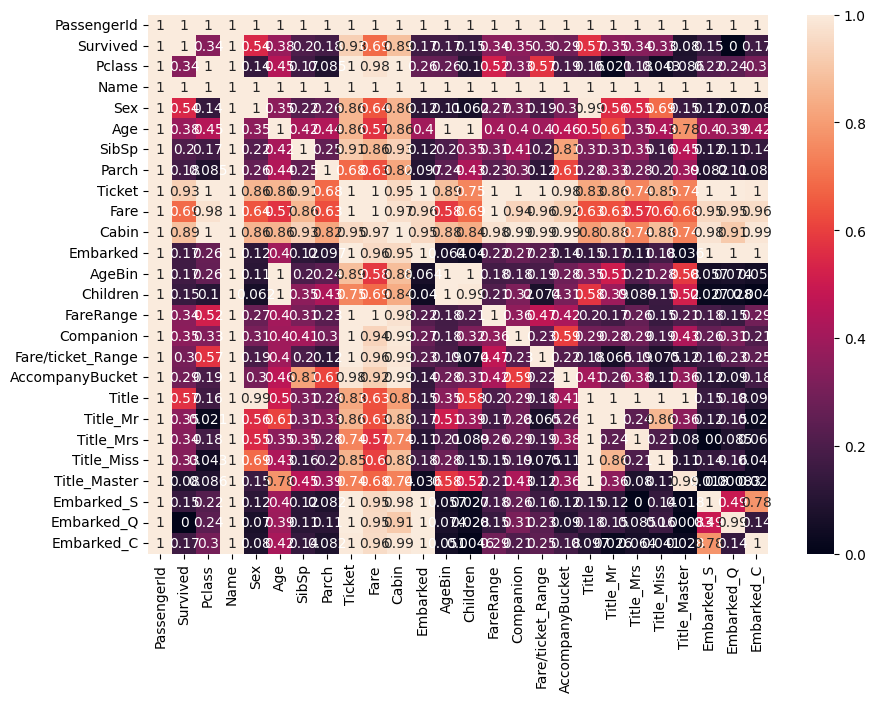

In [50]:
def create_cramers_matrix (df, features: list):
    if not isinstance(features, list): features = [features]
    size = len (features)
    cramer_matrix = np.zeros ((size, size))
    for i, feature1 in enumerate(features):
        for j, feature2 in enumerate(features):
            cramer_matrix[i, j] = cramers(df[feature1], df[feature2])
    return pd.DataFrame(
        cramer_matrix,
        index=features,
        columns=features,
    )
all_features = data.columns.tolist()
cramer_matrix = create_cramers_matrix(data, all_features)
plt.figure (figsize = (10, 7))
sns.heatmap(cramer_matrix, annot = True)

It can be seen that Age is most highly correlated with Parch, Pclass, AccompanyBucket, and Fare, so we will take a look at these features to fill Age. It's worth noticing that even after AccompanyBucket has been sliced, it's still share the second-most correlation with Age. So I will recreate Accompany feature on data for us to see this correlation more clearly

<Axes: >

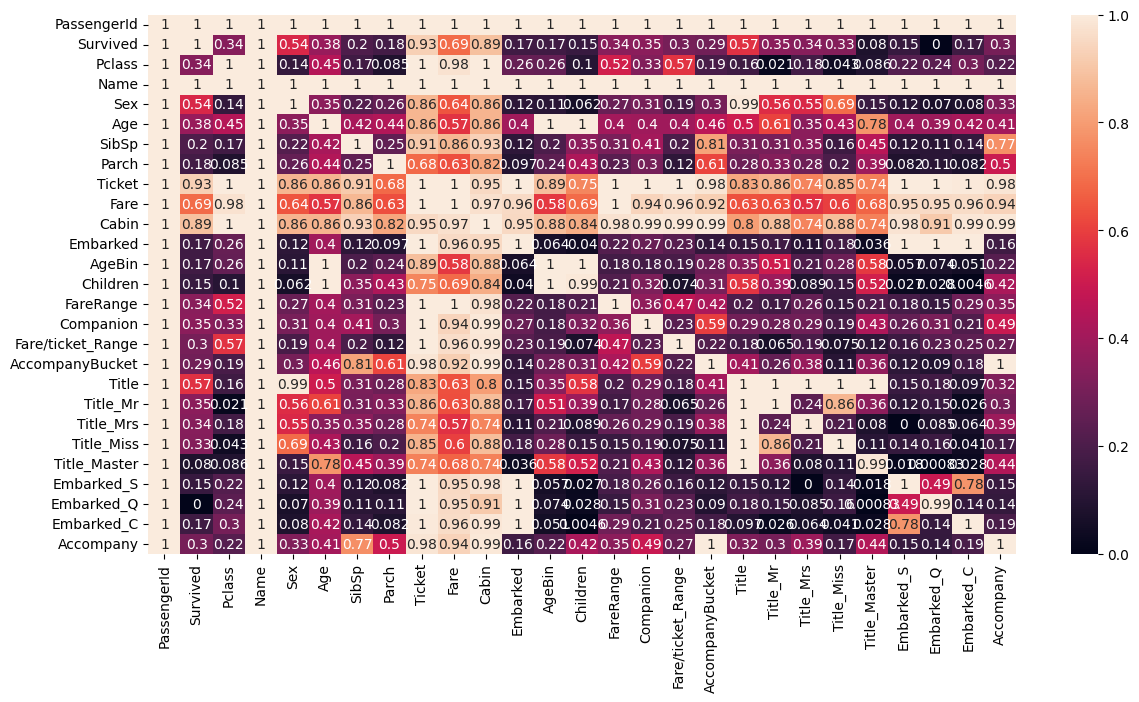

In [51]:
data['Accompany'] = data['SibSp'] + data['Parch']
all_features = data.columns.tolist()
plt.figure (figsize = (14, 7))
cramer_matrix = create_cramers_matrix(data, all_features)
sns.heatmap (cramer_matrix, annot = True)

Surprisingly, Accompany features before being bucketed has less correlation to the one that has been bucketed

<Axes: xlabel='FareRange'>

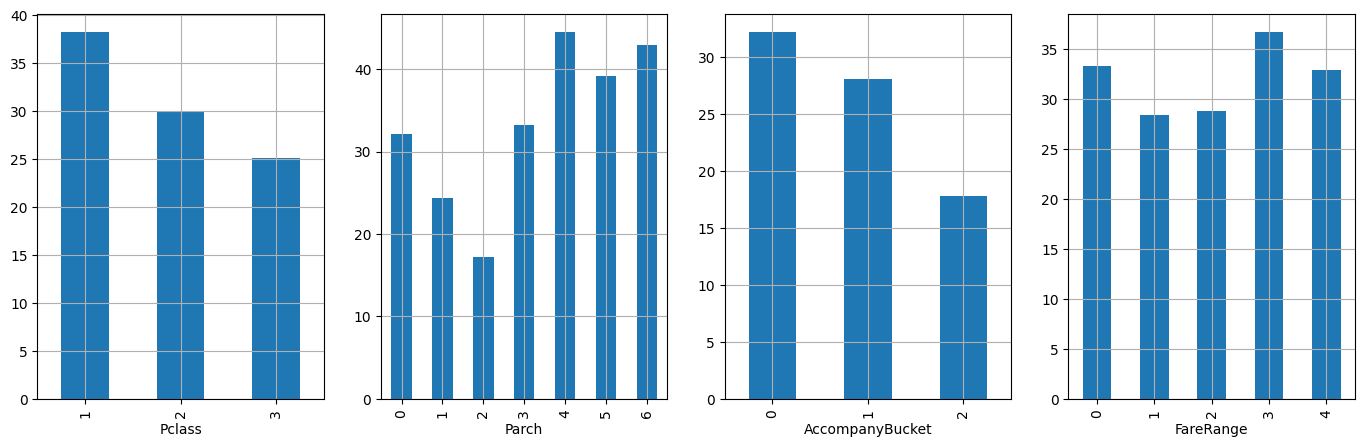

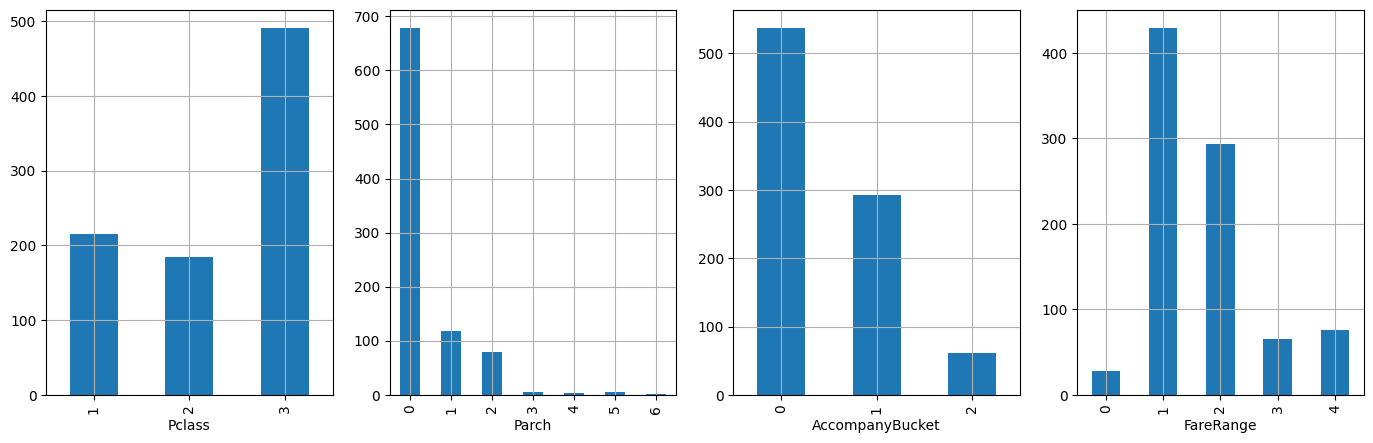

In [52]:
_, axes = plt.subplots (nrows = 1, ncols = 4, figsize = (17, 5))
data.groupby('Pclass')['Age'].mean().plot(kind = 'bar', grid = True, ax = axes[0])
data.groupby('Parch')['Age'].mean().plot(kind = 'bar', grid = True, ax = axes[1])
data.groupby('AccompanyBucket')['Age'].mean().plot(kind = 'bar', grid = True, ax = axes[2])
data.groupby('FareRange')['Age'].mean().plot(kind = 'bar', grid = True, ax = axes[3])

_, axes = plt.subplots (nrows = 1, ncols = 4, figsize = (17, 5))
data.groupby('Pclass')['Pclass'].count().plot(kind = 'bar', grid = True, ax = axes[0])
data.groupby('Parch')['Parch'].count().plot(kind = 'bar', grid = True, ax = axes[1])
data.groupby('AccompanyBucket')['AccompanyBucket'].count().plot(kind = 'bar', grid = True, ax = axes[2])
data.groupby('FareRange')['FareRange'].count().plot(kind = 'bar', grid = True, ax = axes[3])


Looking at 4 features, we can see that:
* 1/ Parch has too imbalanced distribution, making it not the most promising decision.
* 2/ FareRange and Pclass has good number of groups and are not heavily skewed.Filling according to this feature will make Age more diverse
* 3/ AccompanyBucket is also nice but not as good as the other features
* => Knowing that Age is highly correlated with Fare, it seems like FareRange and Pclass are the most promising feature to fill Age


In [53]:
for df in datasets:
    df['Age'] = df.groupby(['FareRange', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.mean()))
    df['Age'] = df.groupby('FareRange')['Age'].transform (lambda x: x.fillna(x.mean()))
    df['AgeBin'] = pd.cut (
        df['Age'],
        bins = [0,7,20,28,38,80,1000],
        labels = [0, 1, 2, 3, 4, 5],
        right = False
    )
    df['Sex'] = df['Sex'].transform (
        lambda x: np.nan if str(x) == 'nan' else 1 if x == 'female' else 0 if x == 'male' else x
    )
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   PassengerId        891 non-null    int64   
 1   Survived           891 non-null    int64   
 2   Pclass             891 non-null    int64   
 3   Name               891 non-null    str     
 4   Sex                891 non-null    int64   
 5   Age                891 non-null    float64 
 6   SibSp              891 non-null    int64   
 7   Parch              891 non-null    int64   
 8   Ticket             891 non-null    str     
 9   Fare               891 non-null    float64 
 10  Cabin              204 non-null    str     
 11  Embarked           891 non-null    str     
 12  AgeBin             891 non-null    category
 13  Children           891 non-null    int64   
 14  FareRange          891 non-null    category
 15  Companion          891 non-null    int64   
 16  Fare/ticket_Range  

There are currently many features for just a small dataset. This will make the model more prone to overfitting.So we will have to group features into new ones.

The code below for squeezing the feature was referenced from another notebook.

In [54]:
submission['Survived'] = None
submission['is_train'] = False
data['is_train'] = True
all_data = pd.concat ([data, submission], axis = 0)

In [55]:
all_data['surname'] = all_data['Name'].apply(lambda x: x.split (',')[0])
all_data['ticket_formatted'] = all_data['Embarked'] \
    + '-' + all_data['Ticket'].astype(str).str.slice_replace(-2, repl='XX') \
    + '-' + all_data['Fare'].astype(str)    
all_data['group_id'] = all_data['surname'] + '-' + all_data['Pclass'].astype(str) + '-' + all_data['ticket_formatted']
all_data['group_id'] = all_data.apply (
    lambda x: 'no_group' if x['Title'] == 'Mr' else x['group_id'], axis = 1
)
all_data['group_freq'] = all_data['group_id'].map (
    all_data['group_id'].value_counts()
)
all_data['group_id'] = all_data.apply (
    lambda x: 'no_group' if x['group_freq'] <= 1 else x['group_id'], axis = 1
)
group = all_data[all_data['group_id'] != 'no_group']
for i, row in all_data.iterrows():
    if (row['Title'] != 'Mr') & (row['group_id'] == 'no_group'):
        if all_data[all_data['ticket_formatted'] == row['ticket_formatted']].shape[0] > 0:
            all_data.at[i, 'group_id'] = all_data[all_data['ticket_formatted'] == row['ticket_formatted']].iloc[0]['group_id']

all_data['group_freq'] = all_data['group_id'].map (all_data['group_id'].value_counts())
all_data['group_survival'] = all_data['group_id'].map (
    all_data[all_data['is_train']].groupby('group_id')['Survived'].mean()
)
all_data['group_survival'] = all_data.apply(
    lambda x: all_data[
        (all_data['group_id'] == 'no_group') &
        (all_data['Pclass'] == x['Pclass']) &
        (all_data['Sex'] == x['Sex'])
    ]['Survived'].mean() if x['group_id'] == 'no_group' else x['group_survival'],
    axis = 1
)
def fill_survival (x):
    if pd.isna (x['group_survival']):
        return all_data [all_data['group_freq'] == x['group_freq']]['group_survival'].mean()
    else: 
        return x['group_survival']
all_data['group_survival'] = all_data.apply (fill_survival, axis = 1)

In [56]:
all_data.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   PassengerId        1309 non-null   int64   
 1   Survived           891 non-null    object  
 2   Pclass             1309 non-null   int64   
 3   Name               1309 non-null   str     
 4   Sex                1309 non-null   int64   
 5   Age                1309 non-null   float64 
 6   SibSp              1309 non-null   int64   
 7   Parch              1309 non-null   int64   
 8   Ticket             1309 non-null   str     
 9   Fare               1309 non-null   float64 
 10  Cabin              295 non-null    str     
 11  Embarked           1309 non-null   str     
 12  AgeBin             1309 non-null   category
 13  Children           1309 non-null   int64   
 14  FareRange          1309 non-null   category
 15  Companion          1309 non-null   int64   
 16  Fare/ticket_Range  1309

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
all_data['AgeBin_Scaled'] = scaler.fit_transform (all_data['AgeBin'].values.reshape(-1,1))
all_data['AccompanyBucket_scaled'] = scaler.fit_transform (all_data['AccompanyBucket'].values.reshape (-1,1))
all_data['FareRange_scaled'] = scaler.fit_transform(all_data['FareRange'].values.reshape(-1,1))
all_data['Fare/ticket_Range_scaled'] = scaler.fit_transform(all_data['FareRange'].values.reshape(-1,1))
all_data['Companion_scaled'] = scaler.fit_transform(all_data['Companion'].values.reshape(-1, 1))
all_data['Pclass_scaled'] = scaler.fit_transform (all_data['Pclass'].values.reshape(-1, 1))
all_data['Group_survival_scaled'] = scaler.fit_transform(all_data['group_survival'].values.reshape(-1,1))

In [58]:
drop_features = all_data.select_dtypes(include = ['category', str]).columns.tolist()
drop_features.append ('Accompany')
for feature in drop_features:
    if feature not in all_data: 
        continue
    all_data.drop (feature, axis = 1, inplace = True)

<Axes: title={'center': 'Total: 27 features'}>

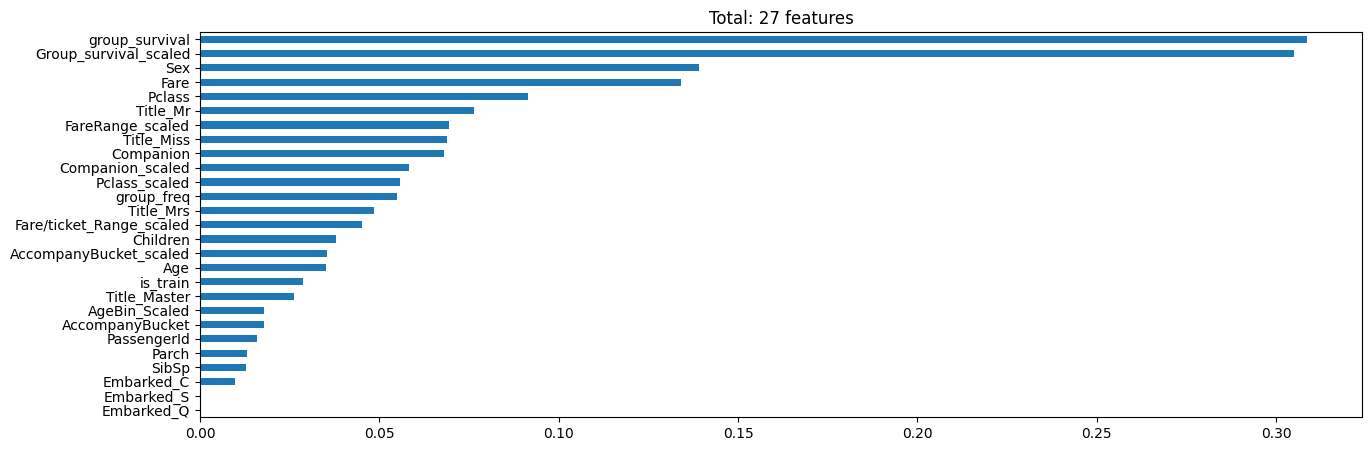

In [59]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt 
data = all_data[:891]
data['Survived'] = data['Survived'].astype(int)
submission = all_data[891:]
mf = mutual_info_classif (data.drop ('Survived', axis = 1), data['Survived'])
mf = pd.Series(mf, index = data.drop('Survived', axis = 1).columns).sort_values(ascending = True)
mf.plot(kind = 'barh', figsize = (15, 5), title = f'Total: {len(data.drop('Survived', axis = 1).columns)} features')

In [60]:
best_features = ['Group_survival_scaled', 'Sex', 'Companion_scaled', 'FareRange_scaled', 'Pclass']
data = data[best_features + ['Survived']]
submission = submission[best_features + ['PassengerId']]

In [61]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    data.drop('Survived', axis = 1).copy(),
    data['Survived'].copy(),
    shuffle = True,
    test_size = 0.3,
    stratify = data['FareRange_scaled'],
)

# Model Selection & Tuning

For this type of supervised binary classification problem. Some of the best models are:
* Random Forest
* Decision Tree 
* XGBoost
* ADA Boost
* Gradient Boosting
* Hist Gradient Boosting
* Logistics Regression
* K Nearest Neighbors
* Supported Vectors Machine
* Naive Bayes
* Linear Discriminant Analysis 
* K Nearest Neighbors Classifier

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

In [63]:
forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    criterion='gini',
    min_samples_leaf=3,
    min_samples_split=10,
)
tree = DecisionTreeClassifier(
    max_depth=10,
    criterion='gini',
    min_samples_leaf=3,
    min_samples_split=10,
)
xg = XGBClassifier()
ada = AdaBoostClassifier()
gb = GradientBoostingClassifier()
hgb = HistGradientBoostingClassifier()
lr = LogisticRegression()
svc = SVC()
knn = KNeighborsClassifier()
lda = LinearDiscriminantAnalysis()

models = [forest, tree, xg, ada, gb, hgb, knn]
def validate (models: list):
    cv_scores, test_scores, model_names, weight, gap = [], [], [], [], []
    if not isinstance(models, list): models = [models]
    for model in models:
        print (f'\n--------{type(model).__name__}-----')
        scores = cross_val_score(
            model, 
            x_train, y_train,
            cv = 10,
            scoring = 'accuracy'
        )

        print ('Train CV:')
        print (f'Scores: {scores}')
        print (f'Scores mean: {scores.mean()}')
        print (f'Scores std: {scores.std()}')

        model.fit (x_train, y_train)
        y_pred = model.predict (x_test)
        print(); print ('Test Scores')
        acc = accuracy_score(y_test, y_pred)
        print (f'Accuracy: {acc}')
        val_score = scores.mean()

        cv_scores.append (val_score)
        test_scores.append (acc)
        model_names.append (type(model).__name__)        
        gap.append (abs (val_score - acc))
        weight.append ((acc) - 0.5 * (val_score - acc))

    model_scores_df = pd.DataFrame({
        'Model': model_names,
        'CV_Score': cv_scores,
        'Test_Score': test_scores,
        'Weighted': weight,
        'Gap': gap,
    })
    ranking_df = model_scores_df.sort_values('Test_Score', ascending = False)
    return ranking_df        

ranking_df = validate (models)
ranking_df


--------RandomForestClassifier-----
Train CV:
Scores: [0.92063492 0.88888889 0.82539683 0.87096774 0.90322581 0.87096774
 0.80645161 0.87096774 0.83870968 0.83870968]
Scores mean: 0.8634920634920634
Scores std: 0.03404398035578932

Test Scores
Accuracy: 0.8097014925373134

--------DecisionTreeClassifier-----
Train CV:
Scores: [0.9047619  0.88888889 0.80952381 0.85483871 0.88709677 0.85483871
 0.79032258 0.83870968 0.77419355 0.83870968]
Scores mean: 0.8441884280593959
Scores std: 0.04098504890397905

Test Scores
Accuracy: 0.8134328358208955

--------XGBClassifier-----
Train CV:
Scores: [0.9047619  0.88888889 0.84126984 0.87096774 0.88709677 0.87096774
 0.80645161 0.83870968 0.79032258 0.83870968]
Scores mean: 0.8538146441372246
Scores std: 0.035228077852089014

Test Scores
Accuracy: 0.8134328358208955

--------AdaBoostClassifier-----
Train CV:
Scores: [0.92063492 0.88888889 0.85714286 0.87096774 0.91935484 0.87096774
 0.80645161 0.87096774 0.83870968 0.83870968]
Scores mean: 0.8682795

,Model,CV_Score,Test_Score,Weighted,Gap
4,GradientBoostingClassifier,0.860241,0.817164,0.795626,0.043076
2,XGBClassifier,0.853815,0.813433,0.793242,0.040382
1,DecisionTreeClassifier,0.844188,0.813433,0.798055,0.030756
5,HistGradientBoostingClassifier,0.855453,0.813433,0.792423,0.042020
0,RandomForestClassifier,0.863492,0.809701,0.782806,0.053791
3,AdaBoostClassifier,0.868280,0.809701,0.780412,0.058578
6,KNeighborsClassifier,0.855402,0.809701,0.786851,0.045700


We are going to do Hyperparameter tuning on the top 6 best models

In [64]:
top_6 = ranking_df.iloc[:6]
top_6

,Model,CV_Score,Test_Score,Weighted,Gap
4,GradientBoostingClassifier,0.860241,0.817164,0.795626,0.043076
2,XGBClassifier,0.853815,0.813433,0.793242,0.040382
1,DecisionTreeClassifier,0.844188,0.813433,0.798055,0.030756
5,HistGradientBoostingClassifier,0.855453,0.813433,0.792423,0.042020
0,RandomForestClassifier,0.863492,0.809701,0.782806,0.053791
3,AdaBoostClassifier,0.868280,0.809701,0.780412,0.058578


In [65]:
# svc_raw = SVC()
# submitting_file(svc_raw, 'svc_raw')
# forest_raw = RandomForestClassifier()
# submitting_file(forest_raw, 'forest_raw')
# lr = LogisticRegression()
# submitting_file(lr_raw, 'lr_raw')
# knn = KNeighborsClassifier()
# submitting_file(knn, 'knn_raw')
# hgb = HistGradientBoostingClassifier()
# submitting_file(hgb, 'hgb_raw')
# gb = GradientBoostingClassifier()
# submitting_file(gb, 'gb_raw')
# ada = AdaBoostClassifier()
# submitting_file(ada, 'ada_raw')
# tree = DecisionTreeClassifier()
# submitting_file(tree, 'tree_raw')

In [66]:
import optuna
import joblib

In [86]:
def submitting_file (model, file_name = ''): 
    if not file_name.endswith('.csv'):
        file_name += '.csv'
    model.fit (data.drop ('Survived', axis = 1), data['Survived'])
    y_pred = model.predict (submission.drop ('PassengerId', axis = 1))
    result = pd.DataFrame({
        'PassengerId': submission['PassengerId'],
        'Survived': y_pred,
    })
    result.to_csv (f'{file_name}', index = False)

In [67]:
from inspect import isclass
def fine_tune(objective, model_class, trial = 100):
    if not isclass (model_class): 
        raise TypeError (f'Expected model_class to be a class, got {type(model_class).__name__}')
        
    name = type(model_class()).__name__ + '.pkl'
    if os.path.exists (name):
        model = joblib.load (name)
        return model

    study = optuna.create_study(
        directions = ['maximize', 'maximize'],
        sampler=optuna.samplers.NSGAIIISampler(),
        pruner=optuna.pruners.MedianPruner(
            n_min_trials=10,
            n_startup_trials=2,
            interval_steps=3,
        )
    )
    study.optimize(
        objective, 
        n_trials=trial,
    )

    pareto = study.best_trials
    df = pd.DataFrame({
        'acc': [t.values[0] for t in pareto],
        'gap': [t.values[1] for t in pareto],
        'trial': [t.number for t in pareto],
    })

    df['gap'] = df['gap'].apply(lambda x: min (x, 0))
    df['perfect_rate'] = np.sqrt (
        (1 - df['acc']) ** 2
        + 
        (df['gap']) ** 2
    )
    best_idx = df['perfect_rate'].idxmin()
    params = pareto[best_idx].params
    model = model_class(**params)
    model.fit (x_train, y_train)
    joblib.dump (model, name)
    return model

In [ ]:
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.ensemble import RandomForestClassifier
def forest_objective (trial):
    params = {
        'n_estimators': trial.suggest_int ('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int ('max_depth', 3, 10),
        'min_samples_leaf': trial.suggest_int ('min_samples_leaf', 1, 10),
        'min_samples_split': trial.suggest_int ('min_samples_split', 2, 10),
        'random_state': trial.suggest_categorical ('random_state', [42])
    }
    model = RandomForestClassifier(**params)
    val_scores = cross_val_score(
        model, 
        x_train, y_train, 
        cv = 10,
        scoring = 'balanced_accuracy',
    )
    val_score = val_scores.mean()
    
    model.fit (x_train, y_train)
    y_pred = model.predict (x_test)
    test_score = accuracy_score(y_test, y_pred)
    gap = test_score - val_score
    return val_score, gap
forest_model = fine_tune (forest_objective, RandomForestClassifier, trial = 200)
submitting_file(forest_model, 'forest_tuned')
from sklearnex import unpatch_sklearn
unpatch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)
C:\Users\alexh\AppData\Local\Temp\ipykernel_7308\380969062.py:13: ExperimentalWarning: NSGAIIISampler is experimental (supported from v3.2.0). The interface can change in the future.
  sampler=optuna.samplers.NSGAIIISampler(),
[I 2026-04-25 18:39:40,802] A new study created in memory with name: no-name-6aab66d9-bcaf-4f25-b167-804b86efd1d2
[I 2026-04-25 18:39:41,140] Trial 0 finished with values: [0.8450899929589862, -0.03538850042167285] and parameters: {'n_estimators': 996, 'max_depth': 8, 'min_samples_leaf': 6, 'min_samples_split': 6, 'random_state': 42}.
[I 2026-04-25 18:39:41,577] Trial 1 finished with values: [0.8325690899489526, -0.03033028397880333] and parameters: {'n_estimators': 1331, 'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 2, 'random_state': 42}.
[I 2026-04-25 18:39:41,793] Trial 2 finished with values: [0.8476540955230888, -0.03795260298577541] and parameters: {'n

KeyboardInterrupt: 

In [ ]:
def tree_objective (trial): 
    max_depth = trial.suggest_int ('max_depth', 3, 25)
    min_samples_leaf = trial.suggest_int ('min_samples_leaf', 1, 15)
    min_samples_split = trial.suggest_int ('min_samples_split', 2, 20)
    random_state = trial.suggest_categorical ('random_state', [42])
    
    model = DecisionTreeClassifier(
        max_depth=max_depth, 
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        random_state=random_state, 
    )

    scores = cross_val_score(
        model, 
        x_train, y_train, 
        cv = 10, 
        scoring = 'balanced_accuracy', 
    )
    val_score = scores.mean()

    model.fit (x_train, y_train)
    y_pred = model.predict (x_test)
    test_score = accuracy_score(y_test, y_pred)
    gap = test_score - val_score

    return val_score, gap
tree_model = fine_tune (tree_objective, DecisionTreeClassifier)

In [70]:
def xg_objective (trial):
    max_depth = trial.suggest_int ('max_depth', 3, 10) 
    learning_rate = trial.suggest_float ('learning_rate', 0.01, 0.3, log = True)
    n_estimators = trial.suggest_int ('n_estimators', 50, 300) 
    subsample = trial.suggest_float ('subsample', 0.5, 1.0)
    colsample_bytree= trial.suggest_float ('colsample_bytree', 0.5, 1.0)
    model = XGBClassifier(
        max_depth = max_depth,
        learning_rate = learning_rate,
        n_estimators = n_estimators,
        subsample = subsample,
        colsample_bytree = colsample_bytree,
    )
    val_scores = cross_val_score(
        model, 
        x_train, y_train, 
        cv = 10, 
        scoring = 'balanced_accuracy',
    )
    scores = val_scores.mean()
    model.fit (x_train, y_train)
    y_pred = model.predict (x_test)
    test_score = accuracy_score(y_test, y_pred)
    gap = test_score - scores
    return scores, gap
xg_model = fine_tune(xg_objective, XGBClassifier)

C:\Users\alexh\AppData\Local\Temp\ipykernel_7308\380969062.py:13: ExperimentalWarning: NSGAIIISampler is experimental (supported from v3.2.0). The interface can change in the future.
  sampler=optuna.samplers.NSGAIIISampler(),
[I 2026-04-25 17:36:52,824] A new study created in memory with name: no-name-6586e598-6dc0-48c9-a96c-aae9ca24cc05
[I 2026-04-25 17:36:54,043] Trial 0 finished with values: [0.8307853664260987, -0.028546560455949388] and parameters: {'max_depth': 7, 'learning_rate': 0.15915834652903746, 'n_estimators': 237, 'subsample': 0.7864201255837452, 'colsample_bytree': 0.5867543799585271}.
[I 2026-04-25 17:36:54,966] Trial 1 finished with values: [0.8351331925130554, -0.029163043259324062] and parameters: {'max_depth': 5, 'learning_rate': 0.15976548236405133, 'n_estimators': 225, 'subsample': 0.6603311906591491, 'colsample_bytree': 0.94121542851264}.
[I 2026-04-25 17:36:55,810] Trial 2 finished with values: [0.8286114533826204, -0.0077159309945606935] and parameters: {'max_

In [71]:
# def ada_objective (trial): 
#     n_estimators = trial.suggest_int ('n_estimators', 10, 300)
#     learning_rate = trial.suggest_float ('learning_rate', 0.001, 2.0, log = True)
#     random_state = trial.suggest_categorical ('random_state', [42])
#     model = AdaBoostClassifier(
#         n_estimators=n_estimators,
#         learning_rate=learning_rate,
#         random_state=random_state,
#     )
#     scores = cross_val_score(
#         model, 
#         x_train, y_train, 
#         cv = 10, 
#         scoring = 'balanced_accuracy', 
#     )
#     val_score = scores.mean()
#     model.fit(x_train, y_train)
#     y_pred = model.predict (x_test)
#     test_score = accuracy_score(y_test, y_pred)
#     gap = test_score - val_score

#     return val_score, gap
# ada_model = fine_tune(ada_objective, AdaBoostClassifier)

In [72]:
# def gb_objective (trial):
#     n_estimators = trial.suggest_int ('n_estimators', 50, 300)
#     learning_rate = trial.suggest_float ('learning_rate', 0.01, 0.3, log = True)
#     max_depth = trial.suggest_int ('max_depth', 3, 10)
#     min_samples_leaf = trial.suggest_int ('min_samples_leaf', 1, 10)
#     min_samples_split = trial.suggest_int ('min_samples_split', 2, 20)
#     model = GradientBoostingClassifier(
#         n_estimators=n_estimators,
#         learning_rate=learning_rate,
#         max_depth=max_depth,
#         min_samples_leaf=min_samples_leaf,
#         min_samples_split=min_samples_split, 
#     )
#     val_scores = cross_val_score(
#         model, 
#         x_train, y_train, 
#         cv = 10, 
#         scoring = 'accuracy', 
#     )
#     val_score = val_scores.mean()
#     model.fit (x_train, y_train)
#     y_pred = model.predict (x_test)
#     test_score = accuracy_score(y_test, y_pred)
#     gap = test_score - val_score
#     return val_score, gap
# gb_model = fine_tune (gb_objective, GradientBoostingClassifier)

In [73]:
def hgb_objective (trial): 
    learning_rate = trial.suggest_float ('learning_rate', 1e-3, 0.3, log = True)
    max_iter = trial.suggest_int ('max_iter', 100, 1000)
    min_samples_leaf = trial.suggest_int ('min_samples_leaf', 5, 30)
    l2_regularization = trial.suggest_float ('l2_regularization', 0.0, 1.0)
    random_state = trial.suggest_categorical ('random_state', [42])

    model = HistGradientBoostingClassifier(
        learning_rate=learning_rate,
        max_iter=max_iter,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=l2_regularization,
        random_state=random_state, 
    )

    scores = cross_val_score(
        model,
        x_train, y_train,
        cv = 10, 
        scoring = 'balanced_accuracy', 
    )
    val_score = scores.mean()
    model. fit (x_train, y_train)
    y_pred = model.predict (x_test)
    test_score = accuracy_score(y_test, y_pred)
    gap = test_score - val_score
    return val_score, gap
hgb_model = fine_tune (hgb_objective, HistGradientBoostingClassifier)

In [74]:
import warnings

In [75]:
warnings.filterwarnings('ignore', message = 'random_state does not')
fine_tuned_models = [forest_model, xg_model, tree_model, hgb_model]
ranking_df = validate (fine_tuned_models)
ranking_df


--------RandomForestClassifier-----


KeyboardInterrupt: 

Now let's use Voting classifier to group these models

In [ ]:
from sklearn.ensemble import VotingClassifier
vote_model = VotingClassifier(
    estimators=[
        ('hgb', hgb_model), 
        ('xg', xg_model),
        ('gb', gb_model),
        ('knn', KNeighborsClassifier()),
        ('tree', DecisionTreeClassifier()),
    ],
    voting = 'soft',
)
submitting_file(vote_model, 'hgb_forest_xg_tuned')

In [ ]:
validate(forest_model)
from sklearn.ensemble import VotingClassifier
forest_svc = VotingClassifier(
    estimators = [
        ('forest', forest_model),
        ('svc', svc_model)
    ],
    voting = 'soft',
    weights = (2,1),
)
validate(forest_svc)


In [ ]:
# from itertools import product
# weight_options = list (product ([1,2], repeat = 3))
# for weight in weight_options:
#     forest_svc = VotingClassifier(
#         estimators = [
#             ('forest', forest_model),
#             ('svc', svc_model),
#             ('lda', lda_model),
#         ],
#         voting = 'soft',
#         weights = weight,
#     )
#     validate (forest_svc)
#     print (weight)

In [ ]:
# warnings.filterwarnings('ignore', message='X has feature')
# from sklearn.ensemble import VotingClassifier
# nb_forest_svc_lda_xg_gb = VotingClassifier(
#     estimators=[
#         ('nb', nb_model),
#         ('forest', forest_model),
#         ('svc', svc_model),
#         ('lda', lda_model),
#         ('xg', xg_model),
#         ('gb', gb_model),
#     ],
#     voting = 'soft'
# )
# submitting_file(nb_forest_svc_lda_xg_gb, 'nb_forest_svc_lda_xg_gb')

# nb_forest_svc_lda_xg = VotingClassifier(
#     estimators=[
#         ('nb', nb_model),
#         ('forest', forest_model),
#         ('svc', svc_model),
#         ('lda', lda_model),
#         ('xg', xg_model),
#         # ('gb', gb_model),
#     ],
#     voting = 'soft'
# )
# submitting_file(nb_forest_svc_lda_xg, 'nb_forest_svc_lda_xg')

# nb_forest_svc_lda = VotingClassifier(
#     estimators=[
#         ('nb', nb_model),
#         ('forest', forest_model),
#         ('svc', svc_model),
#         ('lda', lda_model),
#         # ('xg', xg_model),
#         # ('gb', gb_model),
#     ],
#     voting = 'soft'
# )
# submitting_file(nb_forest_svc_lda, 'nb_forest_svc_lda')

# nb_forest_svc = VotingClassifier(
#     estimators=[
#         ('nb', nb_model),
#         ('forest', forest_model),
#         ('svc', svc_model),
#         # ('lda', lda_model),
#         # ('xg', xg_model),
#         # ('gb', gb_model),
#     ],
#     voting = 'soft'
# )
# submitting_file(nb_forest_svc, 'nb_forest_svc')

# nb_forest = VotingClassifier(
#     estimators=[
#         ('nb', nb_model),
#         ('forest', forest_model),
#         # ('svc', svc_model),
#         # ('lda', lda_model),
#         # ('xg', xg_model),
#         # ('gb', gb_model),
#     ],
#     voting = 'soft'
# )
# submitting_file(nb_forest, 'nb_forest')

# submitting_file(forest, 'forest')

In [ ]:
# forest_svc_lda_xg_gb = VotingClassifier(
#     estimators=[        
#         ('forest', forest_model),
#         ('svc', svc_model), 
#         ('lda', lda_model), 
#         ('xg', xg_model),
#         ('gb', gb_model),
#     ],
#     voting = 'soft'
# )
# submitting_file(forest_svc_lda_xg_gb, 'forest_svc_lda_xg_gb')

# forest_svc_lda_xg = VotingClassifier(
#     estimators=[        
#         ('forest', forest_model),
#         ('svc', svc_model), 
#         ('lda', lda_model), 
#         ('xg', xg_model),
#     ],
#     voting = 'soft'
# )
# submitting_file(forest_svc_lda_xg, 'forest_svc_lda_xg')

# forest_svc_lda = VotingClassifier(
#     estimators=[        
#         ('forest', forest_model),
#         ('svc', svc_model), 
#         ('lda', lda_model), 
#     ],
#     voting = 'soft'
# )
# submitting_file(forest_svc_lda, 'forest_svc_lda')

# forest_svc = VotingClassifier(
#     estimators=[        
#         ('forest', forest_model),
#         ('svc', svc_model), 
#     ],
#     voting = 'soft'
# )
# submitting_file(forest_svc, 'forest_svc')

# forest = RandomForestClassifier()
# forest.fit (data.drop ('Survived', axis = 1), data['Survived'])
# submitting_file(forest, 'forest_raw')

In [ ]:
# warnings.filterwarnings('ignore', message = 'X has feature')
# from sklearn.ensemble import VotingClassifier
# hbc_svc_lr_forest_ada_lda = VotingClassifier(
#     estimators=[
#         ('hbc', hbc_model),
#         ('svc', svc_model),
#         ('lr', lr_model),
#         ('forest', forest_model),
#         ('ada', ada_model),
#         ('lda', lda_model),
#     ],
#     voting = 'soft',
# )
# validate (hbc_svc_lr_forest_ada_lda)

# hbc_svc_lr_forest_ada = VotingClassifier(
#     estimators=[
#         ('hbc', hbc_model),
#         ('svc', svc_model),
#         ('lr', lr_model),
#         ('forest', forest_model),
#         ('ada', ada_model),
#     ],
#     voting = 'soft',
# )
# validate (hbc_svc_lr_forest_ada)

# hbc_svc_lr_forest = VotingClassifier(
#     estimators=[
#         ('hbc', hbc_model),
#         ('svc', svc_model),
#         ('lr', lr_model),
#         ('forest', forest_model),
#     ],
#     voting = 'soft',
# )
# validate (hbc_svc_lr_forest)

# hbc_svc_lr = VotingClassifier(
#     estimators=[
#         ('hbc', hbc_model),
#         ('svc', svc_model),
#         ('lr', lr_model),
#     ],
#     voting = 'soft',
# )
# validate (hbc_svc_lr)


# hbc_svc = VotingClassifier(
#     estimators=[
#         ('hbc', hbc_model),
#         ('svc', svc_model),
#     ],
#     voting = 'soft',
# )
# validate (hbc_svc)

In [ ]:
# ada_hbc = VotingClassifier(
#     estimators=[
#         ('ada', ada_model),
#         ('hbc', hbc_model),
#         # ('lr', lr_model),
#         # ('svc', svc_model),
#         # ('lda', lda_model),
#     ],
#     voting = 'soft',
# )
# validate (ada_hbc)

# ada_hbc_lr = VotingClassifier(
#     estimators=[
#         ('ada', ada_model),
#         ('hbc', hbc_model),
#         ('lr', lr_model),
#         # ('svc', svc_model),
#         # ('lda', lda_model),
#     ],
#     voting = 'soft',
# )
# validate (ada_hbc_lr)

# ada_hbc_lr_svc = VotingClassifier(
#     estimators=[
#         ('ada', ada_model),
#         ('hbc', hbc_model),
#         ('lr', lr_model),
#         ('svc', svc_model),
#         # ('lda', lda_model),
#     ],
#     voting = 'soft',
# )
# validate (ada_hbc_lr_svc)


In [ ]:
submitting_file(hbc_svc_lr_forest_ada_lda, 'hbc_svc_lr_forest_ada_lda')
submitting_file(hbc_svc_lr_forest_ada, 'hbc_svc_lr_forest_ada')
submitting_file(hbc_svc_lr_forest, 'hbc_svc_lr_forest')
submitting_file(hbc_svc_lr, 'hbc_svc_lr')
submitting_file(hbc_svc, 'hbc_svc')
submitting_file(hbc_model, 'hbc')

submitting_file(ada_model, 'ada')
submitting_file(ada_model, 'ada_hbc')
submitting_file(ada_model, 'ada_hbc_lr')
submitting_file(ada_model, 'ada_hbc_lr_svc')